In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st


df_bank = pd.read_csv('bank-additional-full.csv',sep=';')

**Business Problem Understanding**

*Context*

A Portugal bank decided to conduct campaigns using direct phone calls, offering bank clients to place a term deposit. The bank would like to know after all the effort of campaigns which person that being called would like to place a deposit or not based on age, job, education, call duration, month of the call, etc. 

Target:

'no': Would not deposit.

'yes': Would like to deposit.

*Problem Statement*

The bank’s current outbound marketing strategy for term deposits is inefficient, resulting in high operational costs and "marketing fatigue" among clients. Currently, the bank targets a broad audience with a one-size-fits-all approach, leading to a low conversion rate. To maintain a competitive edge and increase capital reserves, the bank must transition from a mass-marketing model to a data-driven targeted strategy. 

Direct marketing campaigns (phone calls) are expensive in terms of human resources and time. The "cost-per-acquisition" is currently suboptimal because:

1. High Noise-to-Signal Ratio: A large majority of contacted clients decline the offer, meaning significant effort is wasted on non-prospective leads.

2. Client Dissatisfaction: Repeatedly contacting uninterested clients can damage the bank's brand reputation and lead to increased "churn" or opt-outs.

3. Undefined Seasonality: The bank most likely doesn't understanding the chronological and socio-economic factors.

*Analytic Approach*

The objective of this project is to analyze historical campaign data to identify the profile of a "likely subscriber." By utilizing refined Exploratory Data Analysis (EDA) and predictive modeling. We aim to identify which socio-economic groups (Education, Job) have the highest propensity to subscribe, determine the ideal months and days to contact specific segments, and minimize risk by removing person with specific credit defaults or loan profiles.

*Goals*

The successful implementation of this analysis will allow the bank to:

1. Increase the Conversion Rate: Achieve more "Yes" responses with fewer calls.

2. Reduce Operational Costs: Lower the total number of hours spent on the phone by agents.

3. Improve Client Experience: Only contact clients with products that are relevant to their financial status.

*Data Understanding*

Data source: https://www.kaggle.com/datasets/volodymyrgavrysh/bank-marketing-campaigns-dataset/data

Note:
* Data set is imbalance.
* The feature that is numerical and categorical is similar in number.
* Each line of data represent the client that has been called for campaign.

In [112]:
df_bank.columns = df_bank.columns.str.replace(".", "_", regex=False)
df_bank.head().T

,0,1,2,3,4
age,56,57,37,40,56
job,housemaid,services,services,admin.,services
marital,married,married,married,married,married
education,basic.4y,high.school,high.school,basic.6y,high.school
default,no,unknown,no,no,no
housing,no,no,yes,no,no
loan,no,no,no,no,yes
contact,telephone,telephone,telephone,telephone,telephone
month,may,may,may,may,may
day_of_week,mon,mon,mon,mon,mon


In [113]:
df_bank.describe()

,age,duration,campaign,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [114]:
df_bank.describe(include='object').T

,count,unique,top,freq
job,41188,12,admin.,10422
marital,41188,4,married,24928
education,41188,8,university.degree,12168
default,41188,3,no,32588
housing,41188,3,yes,21576
loan,41188,3,no,33950
contact,41188,2,cellular,26144
month,41188,10,may,13769
day_of_week,41188,5,thu,8623
poutcome,41188,3,nonexistent,35563


In [115]:
df_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp_var_rate    41188 non-null  float64
 16  cons_price_idx  41188 non-null  float64
 17  cons_conf_idx   41188 non-null 

*Attribute Information*

Dataset:

We have 41188 instances and 21 features. The information says there are no null values.

Bank client data:

* age : Age of the lead (numeric).
* job : type of job (Categorical).
* marital : Marital status (Categorical).
* education : Educational qualification of the lead (Categorical).
* default: Does the lead has any default(unpaid) credit (Categorical).
* housing: Does the lead has any housing loan? (Categorical).
* loan: Does the lead has any personal loan? (Categorical).

Related with the last contact of the current campaign:

* contact: Contact communication type (Categorical).
* month: Last contact month of year (Categorical).
* day_of_week: Last contact day of the week (categorical).
* duration: Last contact duration, in seconds (numeric).

Other attributes:

* campaign: Number of contacts performed during this campaign and for this client (numeric).
* pdays: Number of days that passed by after the client was last contacted from a previous campaign(numeric; 999 means client was not previously contacted).
* previous: Number of contacts performed before this campaign and for this client (numeric).
* poutcome: Outcome of the previous marketing campaign (categorical).

Social and economic context attributes:

* emp.var.rate: Employment variation rate (numeric).
* cons.price.idx: Consumer price index (numeric).
* cons.conf.idx: Consumer confidence index (numeric).
* euribor3m: Euribor 3 month rate (numeric).
* nr.employed: Number of employees (numeric).

Output variable (desired target):

* y: has the client subscribed a term deposit? (binary: 'yes','no').

In [116]:
column_mapping = {
    "age": "Age",
    "job": "Job",
    "marital": "Marital",
    "education": "Education",
    "default": "Default",
    "housing": "Housing loan",
    "loan": "Personal loan",
    "contact": "Contact",
    "month": "Month",
    "day_of_week": "Day",
    "poutcome": "Previous outcome",
    "y": "Outcome of this campaign",
    "pdays": "Previous Days",
    "previous": "Previous contacted volume",
    "emp_var_rate": "Employment variation rate",
    "cons_price_idx": "Consumer price index",
    "cons_conf_idx": "Consumer confidence index",
    "euribor3m": "Euribor 3 month rate",
    "nr_employed": "Number of employment",
    "duration": "Duration",
    "campaign": "Number of Campaign"
}

for col, title in column_mapping.items():
    if col in df_bank.columns:
        print(f"{title}:")
        print(df_bank[col].value_counts())
        print("-" * 40)


Age:
age
31    1947
32    1846
33    1833
36    1780
35    1759
      ... 
91       2
98       2
95       1
87       1
94       1
Name: count, Length: 78, dtype: int64
----------------------------------------
Job:
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64
----------------------------------------
Marital:
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64
----------------------------------------
Education:
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64
----

We found out in Previous Days (pdays) the value of 999 has a count of 39673 and the target "y" outcome is 36548.

Insight:

This mean the 999 value is actually they only get contacted a single time, so that they never contacted again. To make sure that we analyze the properly we need to address this by "flagging" it. We could try make its value 0 but it could confuse the model later, that it could be interpret as "contacted today" instead. In this case we should make its value -1 so that the modeling later doesn't confuse it. But at the same time we also want to know what if the data acted as "contacted today" so we should also created a new column 'was_contacted_before' that has 999 as 0.

In [117]:
def apply_pdays_fix(df):
    print(f"Initial 999 count: {(df['pdays'] == 999).sum()}")

    #Create the binary feature directly in the main df
    #1 if contacted before, 0 if not (pdays was 999)
    df['was_contacted_before'] = (df['pdays'] != 999).astype(int)

    print("--- Transformation Complete ---")
    print(f"New 'was_contacted_before' counts:\n{df['was_contacted_before'].value_counts()}")
    
    return df

# Example usage:
df_bank = apply_pdays_fix(df_bank)

Initial 999 count: 39673
--- Transformation Complete ---
New 'was_contacted_before' counts:
was_contacted_before
0    39673
1     1515
Name: count, dtype: int64


In [118]:
df_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   41188 non-null  int64  
 1   job                   41188 non-null  object 
 2   marital               41188 non-null  object 
 3   education             41188 non-null  object 
 4   default               41188 non-null  object 
 5   housing               41188 non-null  object 
 6   loan                  41188 non-null  object 
 7   contact               41188 non-null  object 
 8   month                 41188 non-null  object 
 9   day_of_week           41188 non-null  object 
 10  duration              41188 non-null  int64  
 11  campaign              41188 non-null  int64  
 12  pdays                 41188 non-null  int64  
 13  previous              41188 non-null  int64  
 14  poutcome              41188 non-null  object 
 15  emp_var_rate       

In [119]:
print('Data columns with null values:',df_bank.isnull().sum(), sep = '\n')

Data columns with null values:
age                     0
job                     0
marital                 0
education               0
default                 0
housing                 0
loan                    0
contact                 0
month                   0
day_of_week             0
duration                0
campaign                0
pdays                   0
previous                0
poutcome                0
emp_var_rate            0
cons_price_idx          0
cons_conf_idx           0
euribor3m               0
nr_employed             0
y                       0
was_contacted_before    0
dtype: int64


In [120]:
#We should count how many 'unknown's exist per column
def check_unknowns(data):
    unknown_counts = {}
    for col in data.columns:
        if data[col].dtype == 'object':
            count = data[data[col] == 'unknown'].shape[0]
            if count > 0:
                unknown_counts[col] = count
    return pd.Series(unknown_counts)

print("Unknown values per column:")
print(check_unknowns(df_bank))

Unknown values per column:
job           330
marital        80
education    1731
default      8597
housing       990
loan          990
dtype: int64


Insights:
- Unknown category is find among some of the feature, we need to make sure to deal with that.
- Campaigns only operate during weekdays.
- The month of January and February are not included in the data, we need to know the reason later.

In [121]:
#Numerical & Categorical count

num_cols = df_bank.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df_bank.select_dtypes(include=['object']).columns.tolist()

#Removing 'y' for the feature list
if 'y' in cat_cols:
    cat_cols.remove('y')

print(f"Numerical Columns: {num_cols}")
print(f"Categorical Columns: {cat_cols}")

Numerical Columns: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed', 'was_contacted_before']
Categorical Columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


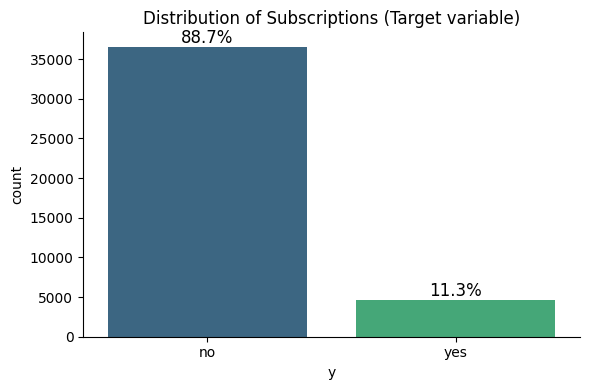

In [122]:
#TARGET DISTRIBUTION
#Before looking at features, we should know the subscription distribution.

plt.figure(figsize=(6, 4))

ax = sns.countplot(
    x='y', 
    data=df_bank, 
    hue='y', 
    palette='viridis', 
    legend=False
)

plt.title('Distribution of Subscriptions (Target variable)')

#Adding percentage labels on top of bars (for clearer visuals)
total = len(df_bank['y'])
for p in ax.patches:
    #Handle potential null heights (good practice)
    height = p.get_height() if p.get_height() > 0 else 0
    percentage = '{:.1f}%'.format(100 * height / total)
    
    #Calculate center of the bar
    x_pos = p.get_x() + p.get_width() / 2
    y_pos = height
    
    ax.annotate(
        percentage, 
        (x_pos, y_pos), 
        ha='center', 
        va='bottom', 
        size=12
    )

sns.despine()
plt.tight_layout()
plt.show()

We can see from the distribution of Subsriptions/Deposit 88.7% says "no" and 11.3% says "yes".

**Analysis for "age"**

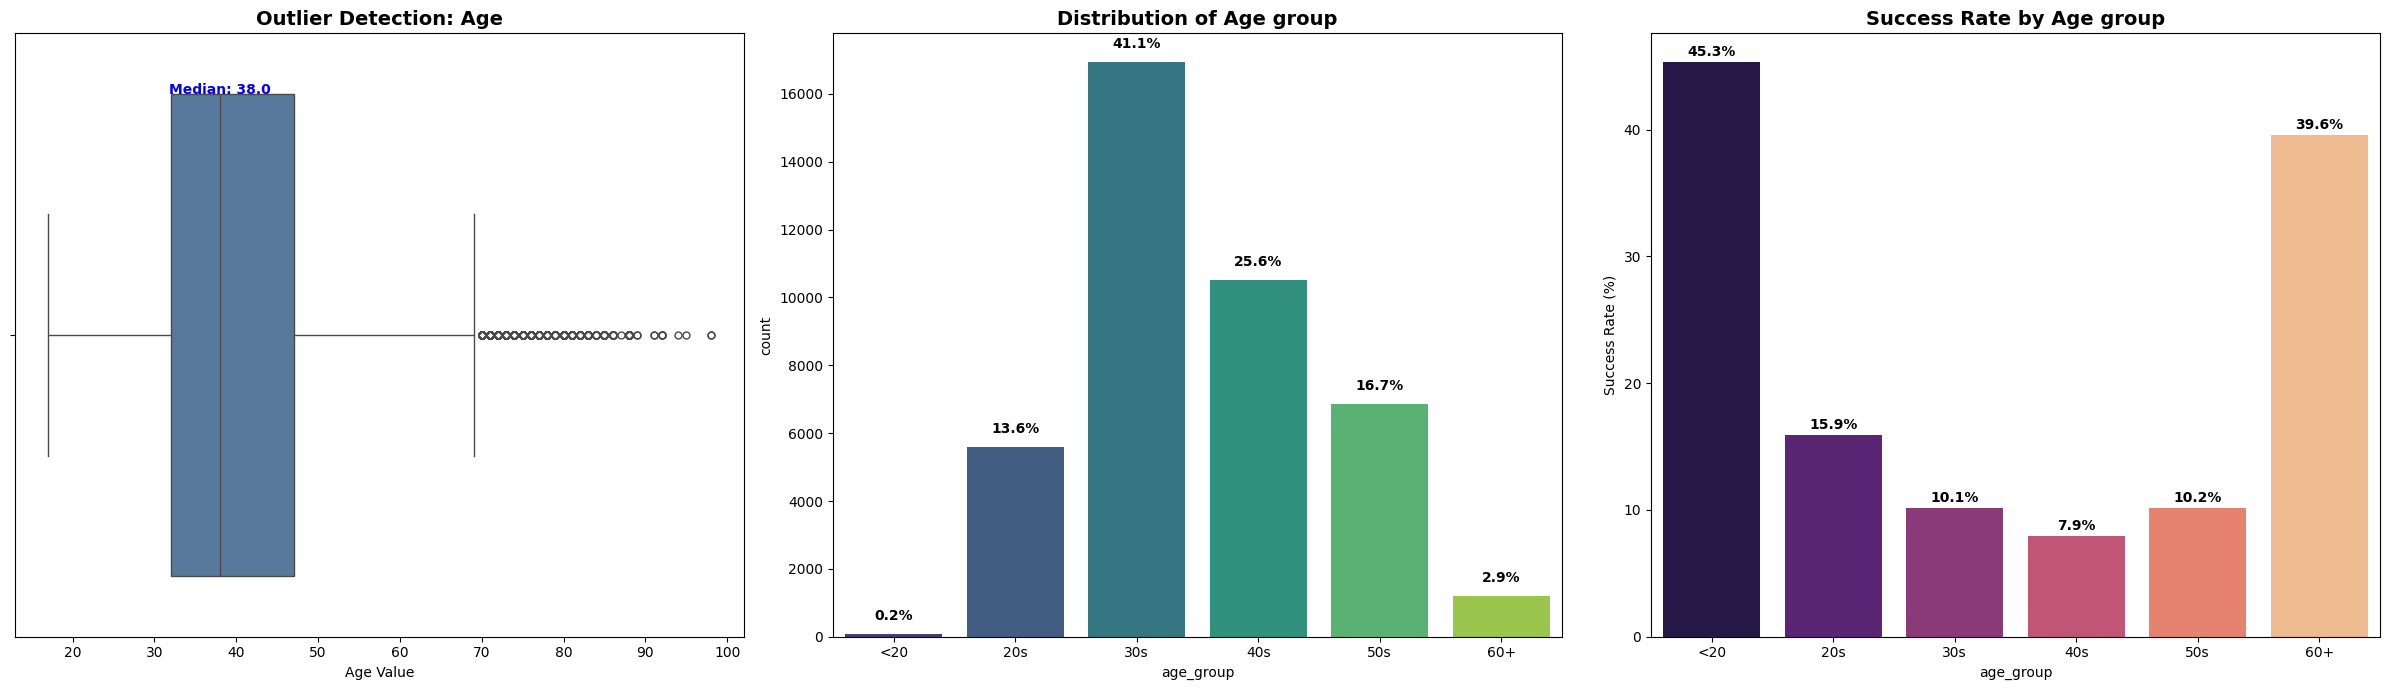

In [123]:
column_numeric = 'age'
column_cat = 'age_group'

#Ensure the binary target exists
if 'target_binary' not in df_bank.columns:
    df_bank['target_binary'] = df_bank['y'].apply(lambda x: 1 if x == 'yes' else 0)

#Create age bins
bins = [0, 20, 30, 40, 50, 60, 100]
labels = ['<20', '20s', '30s', '40s', '50s', '60+']
df_bank['age_group'] = pd.cut(df_bank['age'], bins=bins, labels=labels, right=False)

#Prepare data for labels
counts = df_bank[column_cat].value_counts().reindex(labels)
total = len(df_bank)
success_stats = df_bank.groupby(column_cat, observed=True)['target_binary'].mean() * 100
success_stats = success_stats.reindex(labels)

#Plotting: 1 row, 3 columns
plt.figure(figsize=(24, 7))

#Outlier Detection (Box Plot)
plt.subplot(1, 3, 1)
sns.boxplot(x=df_bank[column_numeric], color='#4e79a7', fliersize=5)
plt.title(f'Outlier Detection: {column_numeric.capitalize()}', fontsize=14, fontweight='bold')
plt.xlabel('Age Value')
#Annotate the median to give more context
median_val = df_bank[column_numeric].median()
plt.text(median_val, -0.4, f'Median: {median_val}', ha='center', color='blue', fontweight='bold')

#Distribution (Bar Chart)
plt.subplot(1, 3, 2)
sns.countplot(data=df_bank, x=column_cat, order=labels, palette='viridis', hue=column_cat, legend=False)
plt.title(f'Distribution of {column_cat.replace("_", " ").capitalize()}', fontsize=14, fontweight='bold')
for i, category in enumerate(labels):
    count = counts[category]
    pct = (count / total) * 100
    plt.text(i, count + (total * 0.01), f'{pct:.1f}%', ha='center', fontweight='bold')

#Success Rate (Bar Chart)
plt.subplot(1, 3, 3)
sns.barplot(x=success_stats.index, y=success_stats.values, palette='magma', hue=success_stats.index, legend=False)
plt.title(f'Success Rate by {column_cat.replace("_", " ").capitalize()}', fontsize=14, fontweight='bold')
plt.ylabel('Success Rate (%)')
for i, val in enumerate(success_stats.values):
    text_val = f'{val:.1f}%' if not np.isnan(val) else '0.0%'
    plt.text(i, (val if not np.isnan(val) else 0) + 0.5, text_val, ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Note: We are creating a new column 'age group(to allow us to use bins)' and 'target binary(essentially just the target y but change no to 0 and yes to 1)' but we have to make sure to remove this in the final before modeling. This is just for analyze EDA.

We can see from the barplot the age distribution that the campaign target mostly adult from age 30 to 45. The most successful on the campaign is actually on people that is less than 20 years old and >60 years old. On the other hand, in the age of 20 to 50 the success rate is around 8.2% to 14.7%. Because we see people that is 70+ has higher success rate of subscription(deposit) even though they are outliers, so we need to keep them in the data for the modeling.

Insight and wisdom:
 
The common explanation for people that is less than 20 years old and 60+ years old most likely deposit is because they most likely is "student or retired" so they can still have a fixed income even though they don't have a job. While the other age group range has a lot more option with their financial decision (like high risk investment) instead of depositing to the bank. So for future calls we need to target a lot more younger(<20 years old) and older people (>60 years old).

**Analysis for Job**

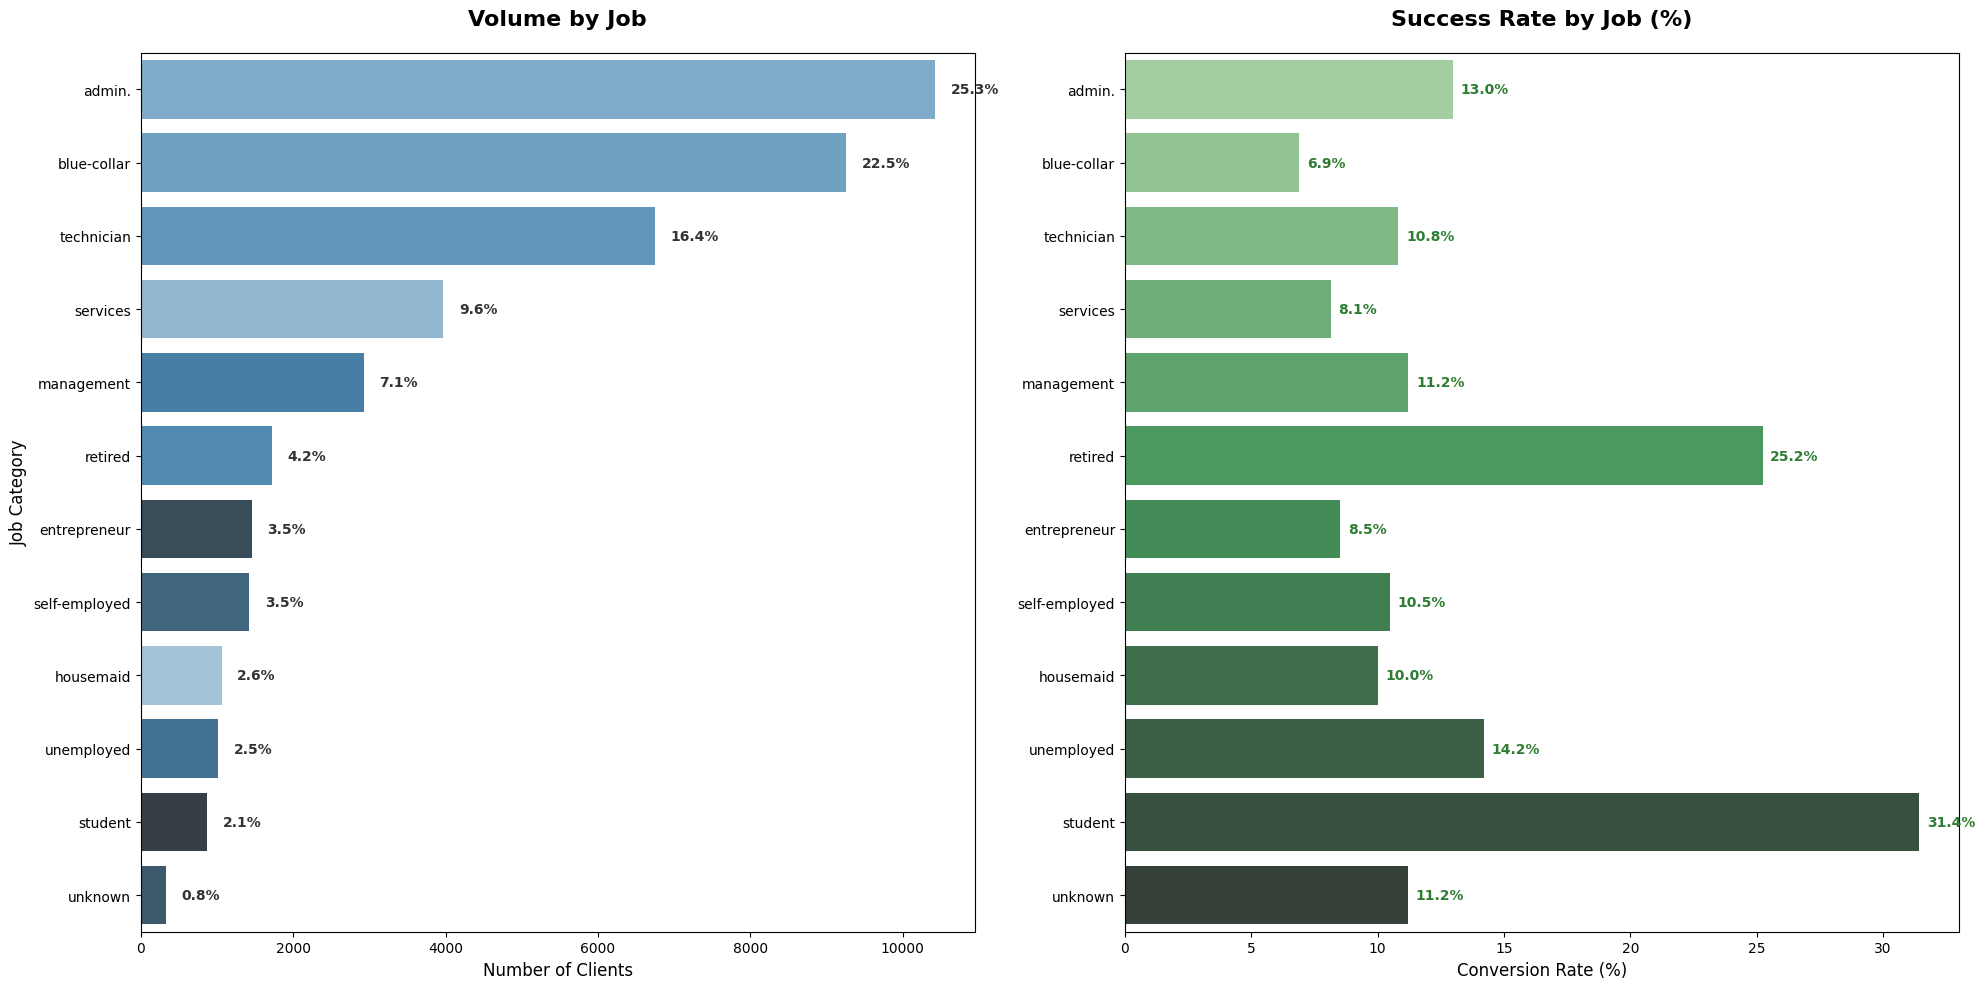

In [124]:
column_cat = 'job' 

#Pre-processing
if 'target_binary' not in df_bank.columns:
    df_bank['target_binary'] = df_bank['y'].apply(lambda x: 1 if x == 'yes' else 0)

#Calculate stats
counts = df_bank[column_cat].value_counts()
order = counts.index
total = len(df_bank)
success_stats = df_bank.groupby(column_cat, observed=True)['target_binary'].mean() * 100
success_stats = success_stats.reindex(order)

#Plotting: 1 row, 2 columns
plt.figure(figsize=(20, 10))

#Frequency Distribution (Horizontal)
plt.subplot(1, 2, 1)
sns.countplot(
    data=df_bank, 
    y=column_cat, 
    order=order, 
    palette='Blues_d', 
    hue=column_cat, 
    legend=False
)
plt.title(f'Volume by {column_cat.capitalize()}', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Number of Clients', fontsize=12)
plt.ylabel('Job Category', fontsize=12)

#Add percentage labels next to bars
for i, category in enumerate(order):
    count = counts[category]
    pct = (count / total) * 100
    plt.text(count + (total * 0.005), i, f'{pct:.1f}%', va='center', fontweight='bold', color='#333')

#Success Rate (Horizontal)
plt.subplot(1, 2, 2)
sns.barplot(
    x=success_stats.values, 
    y=success_stats.index, 
    palette='Greens_d', 
    hue=success_stats.index, 
    legend=False
)
plt.title(f'Success Rate by {column_cat.capitalize()} (%)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Conversion Rate (%)', fontsize=12)
plt.ylabel('') # Shared axis with left plot

#Add rate labels next to bars
for i, val in enumerate(success_stats.values):
    text_val = f'{val:.1f}%' if not np.isnan(val) else '0.0%'
    plt.text(val + 0.3, i, text_val, va='center', fontweight='bold', color='#2e7d32')

plt.tight_layout()
plt.show()

We can see from the countplot that admin, blue-collar and technician is the most targeted from the campaigns these three alone make up for more than 50% of the potential client. But when we see the success rate on the barplot student, retired and unemployed have higher success rate of conversion. Interestingly while admin and technician has average success rate being around 10-13%, blue-collar has the lowest of being 6.9%. Unknown only has 0.8% of the count with 11.2%, we will not be able to deduce anything from this category we should drop it.

Insight and Wisdom:

Even though Students, unemployed and retired rarely get calls they have the highest success rate indicating our previous analysis of the age is also valid. These 3 category doesn't have a job and active income, that's why they most likely accept the bank advise to deposit in order to get more income. While blue-collar has the opposite problem, they have active income but they get paid hourly and they might not work everyday so their money ended up being prioritize for basic commodities, so they ended up not depositing (also applies to services worker). So in the future the campaigns should target more students, unemployed and retired person while reducing the call volume for  blue-collar and services worker.

**Analysis for Marital**

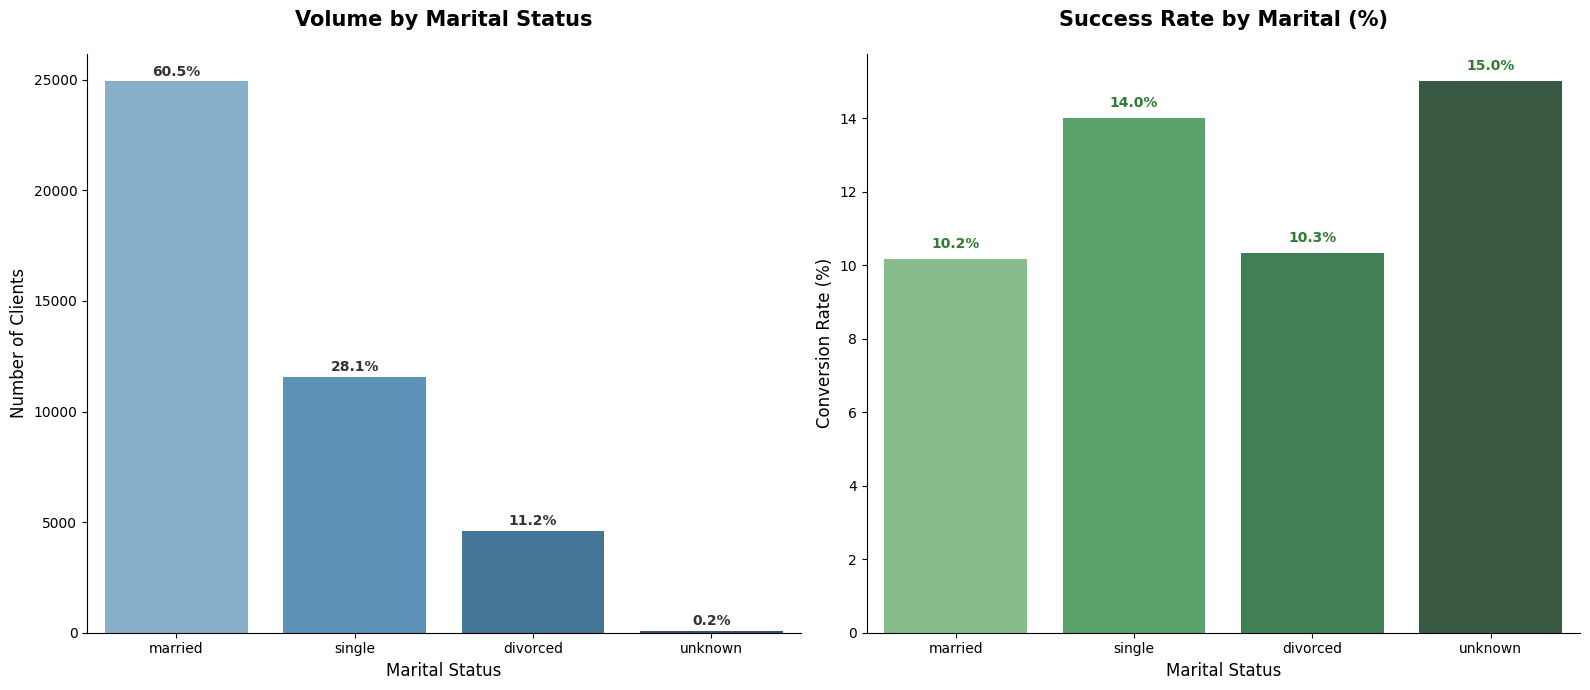

In [125]:
column_cat = 'marital' 

#Pre-processing
if 'target_binary' not in df_bank.columns:
    df_bank['target_binary'] = df_bank['y'].apply(lambda x: 1 if x == 'yes' else 0)

#Calculate stats for ordering and labeling
counts = df_bank[column_cat].value_counts()
order = counts.index
total = len(df_bank)
success_stats = df_bank.groupby(column_cat, observed=True)['target_binary'].mean() * 100
success_stats = success_stats.reindex(order)

#Plotting: 1 row, 2 columns (Vertical bars for x-axis categories)
plt.figure(figsize=(16, 7))

#Frequency Distribution (Vertical)
plt.subplot(1, 2, 1)
sns.countplot(
    data=df_bank, 
    x=column_cat, 
    order=order, 
    palette='Blues_d', 
    hue=column_cat, 
    legend=False
)
plt.title(f'Volume by {column_cat.capitalize()} Status', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Marital Status', fontsize=12)
plt.ylabel('Number of Clients', fontsize=12)

#Add percentage labels above bars
for i, category in enumerate(order):
    count = counts[category]
    pct = (count / total) * 100
    plt.text(i, count + (max(counts) * 0.01), f'{pct:.1f}%', ha='center', fontweight='bold', color='#333')

#Success Rate (Vertical)
plt.subplot(1, 2, 2)
sns.barplot(
    x=success_stats.index, 
    y=success_stats.values, 
    palette='Greens_d', 
    hue=success_stats.index, 
    legend=False
)
plt.title(f'Success Rate by {column_cat.capitalize()} (%)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Marital Status', fontsize=12)
plt.ylabel('Conversion Rate (%)', fontsize=12)

#Add rate labels above bars
for i, val in enumerate(success_stats.values):
    text_val = f'{val:.1f}%' if not np.isnan(val) else '0.0%'
    plt.text(i, val + (max(success_stats) * 0.02), text_val, ha='center', fontweight='bold', color='#2e7d32')

sns.despine()
plt.tight_layout()
plt.show()

We can see from the count plot that married has the highest being 60.5% or around 25000 responder followed by single and divorce. For unknown, person likely doesn't mention their marital status so we should remove them from the data later. Single has the highest success rate of 14% while married and divorced has similar around 10% success rate.

Insight and wisdom:

Overall from the barplot we see that single has 4% higher success rate than married and divorced the likely reason is because the single in this data tend to be younger, has lower financial commitments (look for longer and secure investment) and has easier/faster decision making. Compare this to the married and divorced that tend to be older and more restrictive on their decision making. So in the future people that have single marital status should be prioritize higher, but we still cannot neglected married and divorced group as well during the next campaigns.

**Analysis for education**

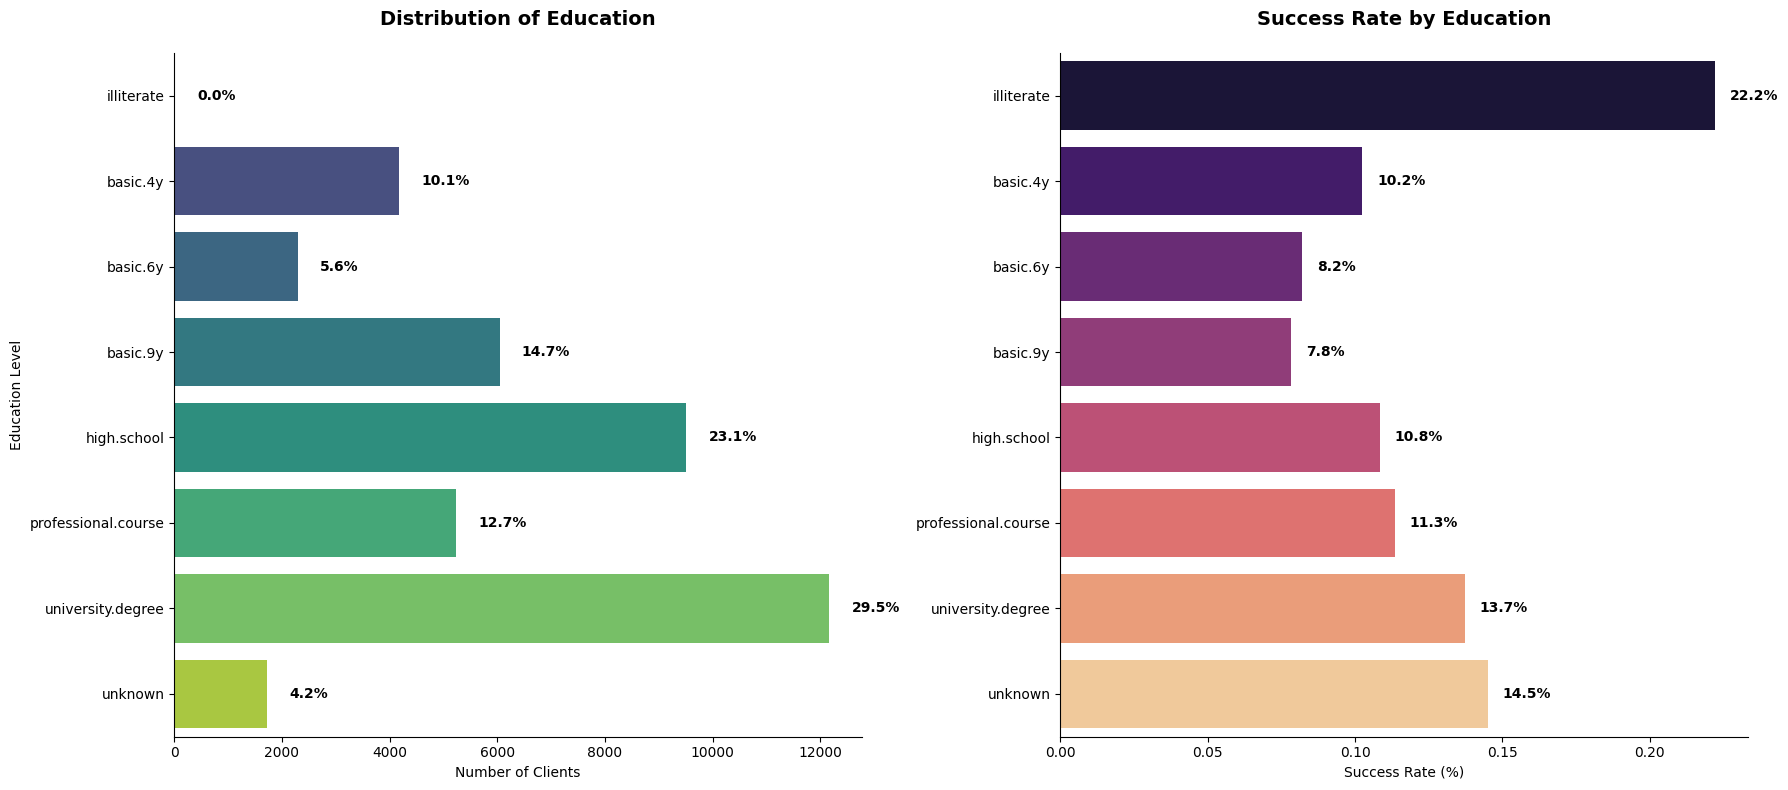

In [126]:
column = 'education'

if 'target_binary' not in df_bank.columns:
    df_bank['target_binary'] = df_bank['y'].apply(lambda x: 1 if x == 'yes' else 0)

edu_order = [
    'illiterate', 'basic.4y', 'basic.6y', 'basic.9y', 
    'high.school', 'professional.course', 'university.degree', 'unknown'
]

edu_stats = df_bank.groupby(column).agg({
    'target_binary': ['count', 'mean']
}).reset_index()
edu_stats.columns = [column, 'total_count', 'success_rate']

available_order = [e for e in edu_order if e in edu_stats[column].unique()]
edu_stats = edu_stats.set_index(column).reindex(available_order).reset_index()

total_clients = edu_stats['total_count'].sum()
edu_stats['percent_of_total'] = (edu_stats['total_count'] / total_clients)

plt.figure(figsize=(18, 8))

#Distribution (Horizontal)
plt.subplot(1, 2, 1)
sns.barplot(
    data=edu_stats, 
    y=column,           # Education on Y-axis
    x='total_count',    # Volume on X-axis
    palette='viridis',
    hue=column,
    legend=False
)
plt.title(f'Distribution of {column.capitalize()}', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Number of Clients')
plt.ylabel('Education Level')

for i, p in enumerate(edu_stats['percent_of_total']):
    count = edu_stats['total_count'][i]
    plt.text(count + (total_clients * 0.01), i, f'{p:.1%}', 
             va='center', ha='left', fontsize=10, fontweight='bold')

#Success Rate (Horizontal)
plt.subplot(1, 2, 2)
sns.barplot(
    data=edu_stats, 
    y=column,           # Education on Y-axis
    x='success_rate',   # Rate on X-axis
    palette='magma',
    hue=column,
    legend=False
)
plt.title(f'Success Rate by {column.capitalize()}', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Success Rate (%)')
plt.ylabel('') #Leave empty to avoid redundancy with the left plot

for i, rate in enumerate(edu_stats['success_rate']):
    plt.text(rate + 0.005, i, f'{rate:.1%}', 
             va='center', ha='left', fontsize=10, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

Immediately we compare distribution and success rate, the top 3 of success rate being illeterate, unkown and university degree. The lowest is basic 4y,6y and 9y. The highest number for targeted campaign is university degree with 29.5% or around 12000 person. The campaign target being university graduate seems like a huge success with it being top 3. Even though illeterate has the highest success rate, unfortunately it's not enough data to be consider so we have to remove them for modeling. Unknown has very high success rate while being 4.2% of the data which mean we cannot ignore it so we should change it later to "does_not_disclose" because it is very likely that the bank doesn't have the data on them but they could still be important.

Insight and wisdom:

So after we ignore illeterate we see that people that has lower education like 4y, 6y and 9y tend to have lower success rate while people that graduate high school, professional course and university degree have higher success rate. This could be attributed to the priority on each person, people with lower education tend to have lower financial gain and focus more on basic commodity first before they could think of deposit to the bank. While people with higher education has higher financial gain tend to be more flexible with their money so that they could think more to the future and likely deposit to the bank. So in the future we should still proritize people with higher education and lowering the campaign effort for people with lower education.



**Analysis for Default**

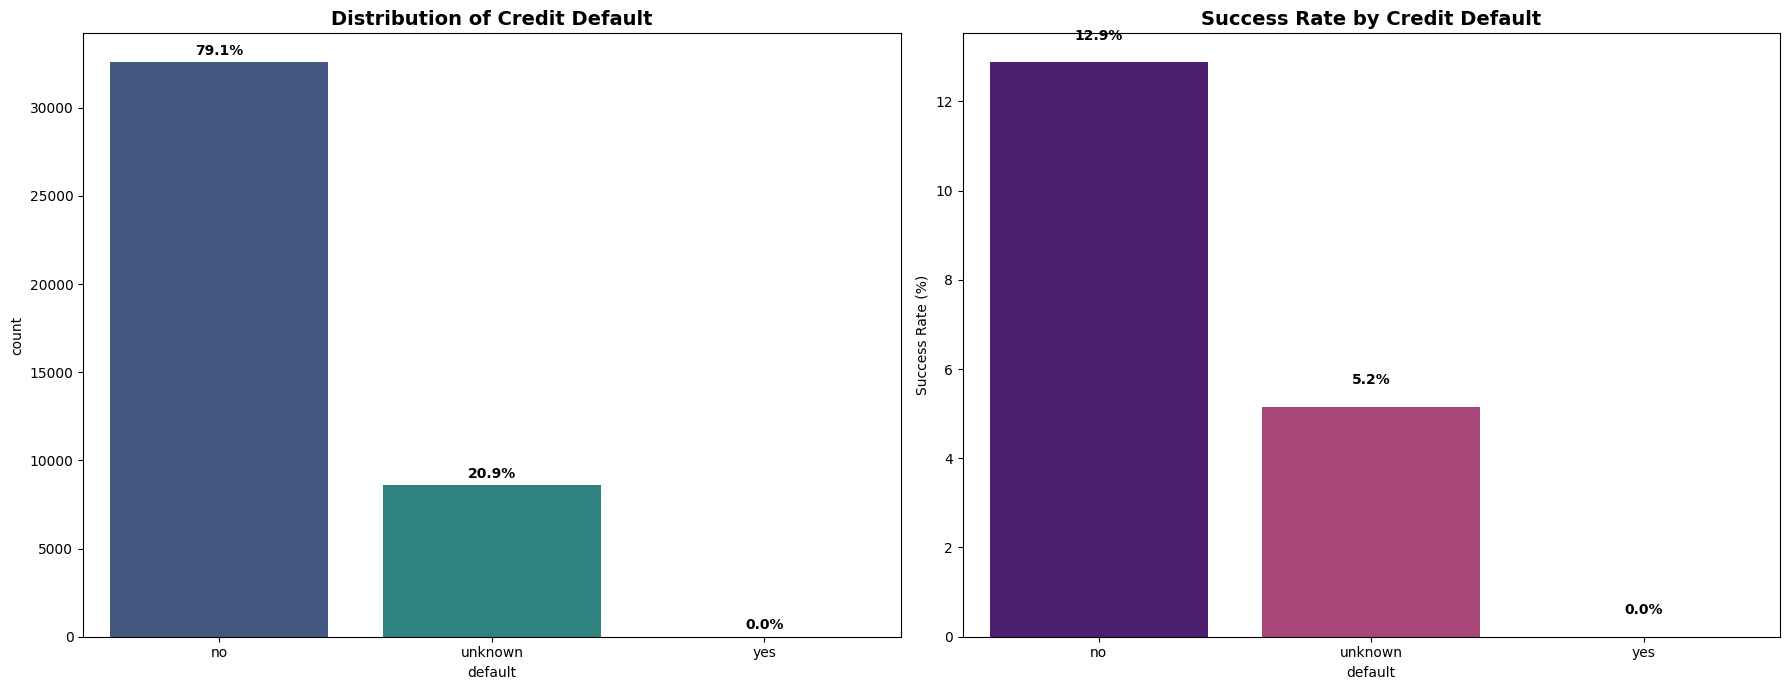

In [127]:
#Credit Default Analysis
column = 'default'

#Ensure the binary target exists for calculation
if 'target_binary' not in df_bank.columns:
    df_bank['target_binary'] = df_bank['y'].apply(lambda x: 1 if x == 'yes' else 0)

counts = df_bank[column].value_counts()
order = counts.index
total = len(df_bank)
success_stats = df_bank.groupby(column)['target_binary'].mean() * 100
success_stats = success_stats.reindex(order)

plt.figure(figsize=(18, 7))

#Distribution
plt.subplot(1, 2, 1)
sns.countplot(data=df_bank, x=column, order=order, palette='viridis', hue=column, legend=False)
plt.title(f'Distribution of Credit {column.capitalize()}', fontsize=14, fontweight='bold')
for i, category in enumerate(order):
    count = counts[category]
    pct = (count / total) * 100
    plt.text(i, count + (total * 0.01), f'{pct:.1f}%', ha='center', fontweight='bold')

#Success Rate
plt.subplot(1, 2, 2)
sns.barplot(x=success_stats.index, y=success_stats.values, palette='magma', hue=success_stats.index, legend=False)
plt.title(f'Success Rate by Credit {column.capitalize()}', fontsize=14, fontweight='bold')
plt.ylabel('Success Rate (%)')
for i, val in enumerate(success_stats.values):
    #Handling potential NaN if a category has zero samples
    text_val = f'{val:.1f}%' if not np.isnan(val) else '0.0%'
    plt.text(i, (val if not np.isnan(val) else 0) + 0.5, text_val, ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

We can see from the chart that we don't have enough data for the people that has credit default, we should remove this in the final product. Most people that are targeted in this campaign has not default yet being 79.1% or more than 30000 people. People with unknown default setting is quite massive with around 8000 people with 5.2% success rate, this is going to be important. Unknown here has a lot of person that mean the bank just could not get the data from the person but because we cannot ignore it, we should change them from unknown to "unverified".

Insight and wisdom:

It makes total sense to target people with has never defaulted because if they are defaulted most likely in debt and has to pay other thing first before they could think about depositing to the bank, the bank itself might be the one that defaulted them. So for the most part bank has succeeded to target the right potential client should keep doing the same thing targeting people that never default but in the future they might want to gather more information about this because we have to many "unverified" in the data.

**Analysis for Housing Loan**

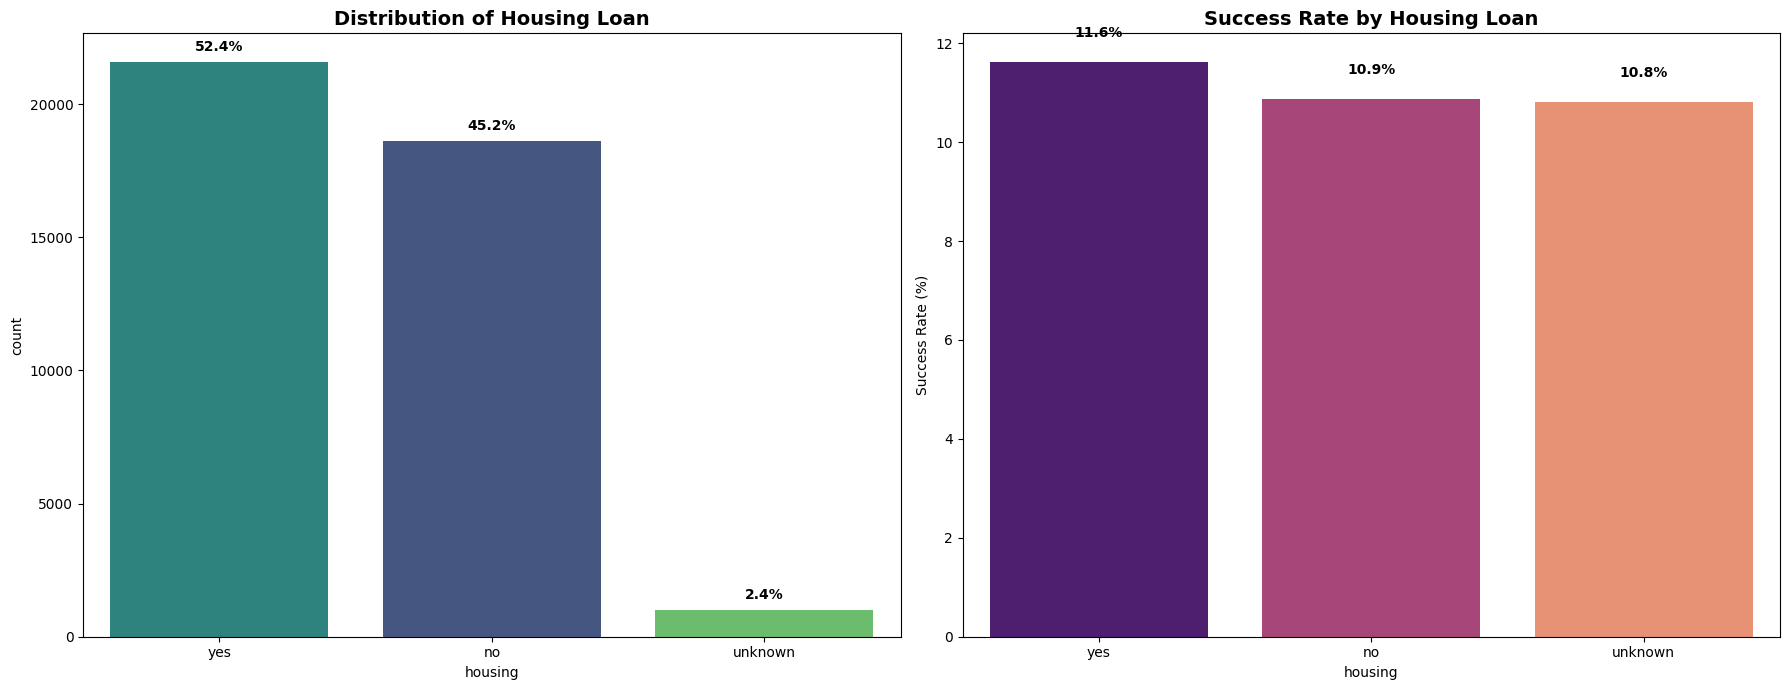

In [128]:
#Housing Loan Analysis
#Convert target for calculation
df_bank['target_binary'] = df_bank['y'].apply(lambda x: 1 if x == 'yes' else 0)

#Calculate stats
column = 'housing'
counts = df_bank[column].value_counts()
order = counts.index
total = len(df_bank)
success_stats = df_bank.groupby(column)['target_binary'].mean() * 100
success_stats = success_stats.reindex(order)

plt.figure(figsize=(18, 7))

#Distribution
plt.subplot(1, 2, 1)
sns.countplot(data=df_bank, x=column, order=order, palette='viridis', hue=column, legend=False)
plt.title(f'Distribution of {column.capitalize()} Loan', fontsize=14, fontweight='bold')
for i, category in enumerate(order):
    count = counts[category]
    pct = (count / total) * 100
    plt.text(i, count + (total * 0.01), f'{pct:.1f}%', ha='center', fontweight='bold')

#Success Rate
plt.subplot(1, 2, 2)
sns.barplot(x=success_stats.index, y=success_stats.values, palette='magma', hue=success_stats.index, legend=False)
plt.title(f'Success Rate by {column.capitalize()} Loan', fontsize=14, fontweight='bold')
plt.ylabel('Success Rate (%)')
for i, val in enumerate(success_stats.values):
    plt.text(i, val + 0.5, f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

People that has housing loan is around 52.4% or 23000 person while the one without housing loan is around 45.2% or 18000 person. The one with housing loan has the highest success rate by 11.6% followed by one without housing loan by 10.9%. Unknown being only 2.4% has almost the same success rate of 10.9%. Unknown is quite important here with almost the same success rate as no housing loan so we can conclude that they might not have houses, so in the future we should change unknown to "does_not_own_house".

Insight and wisdom:

It seems that people with or without housing loan tend to not be that much of different in term of success rate. People with housing loan might still need to pay for their house because of economic factor they still need to do some investing and made more money, so the bank is also one of the option. Overall with how similar they are, campaign should not be determined by if people having house loan or not instead use other data point that has more insight to judge the next call but if we have to choose target people with more housing loan.

**Analysis for Personal Loan**

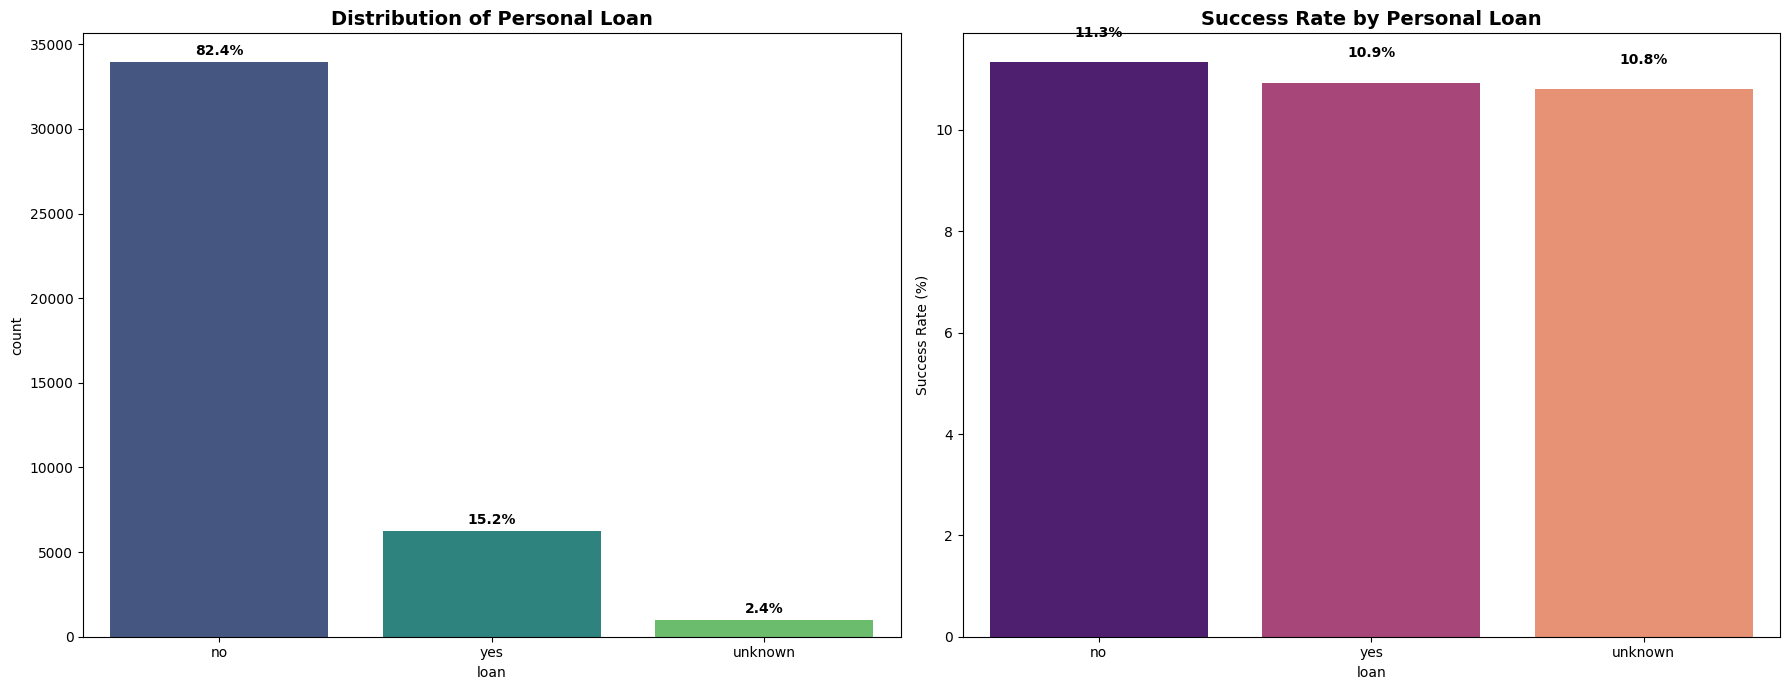

In [129]:
#Personal Loan Analysis
column = 'loan'
counts = df_bank[column].value_counts()
order = counts.index
total = len(df_bank)
success_stats = df_bank.groupby(column)['target_binary'].mean() * 100
success_stats = success_stats.reindex(order)

plt.figure(figsize=(18, 7))

#Distribution
plt.subplot(1, 2, 1)
sns.countplot(data=df_bank, x=column, order=order, palette='viridis', hue=column, legend=False)
plt.title(f'Distribution of Personal {column.capitalize()}', fontsize=14, fontweight='bold')
for i, category in enumerate(order):
    count = counts[category]
    pct = (count / total) * 100
    plt.text(i, count + (total * 0.01), f'{pct:.1f}%', ha='center', fontweight='bold')

#Success Rate
plt.subplot(1, 2, 2)
sns.barplot(x=success_stats.index, y=success_stats.values, palette='magma', hue=success_stats.index, legend=False)
plt.title(f'Success Rate by Personal {column.capitalize()}', fontsize=14, fontweight='bold')
plt.ylabel('Success Rate (%)')
for i, val in enumerate(success_stats.values):
    plt.text(i, val + 0.5, f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

People that has personal loan towering around 82.4% or around 34000 people, while the one that has loan is around 7000 people or 15.2%. With the highest success rate of 11.3% of people that has no loans followed by success rate of 10.9% and 10.8% of people with loans and then unknown. Unknown here has enough data to be important but is it because the bank has no data on the participant? We don't have the support for it but because we only have two option in this case and the success rate is about the same we should move the remaining unknown into people without personal loan instead.

Insight and wisdom:

The bank targeted more people that has no loan and they ended up has the higher success rate but when we look at people with loans they also has a success rate that is not that much different of 0.4%. People with or without personal loan still need to make money and depositing is an available option for both of them. So because the success rate of having personal loan and not ended up being similar, we instead should look for other instrument when we want to make decision for targeting campaign. However if we have to choose we should target more people that has no personal loan.

**Analysis for Contact Method**

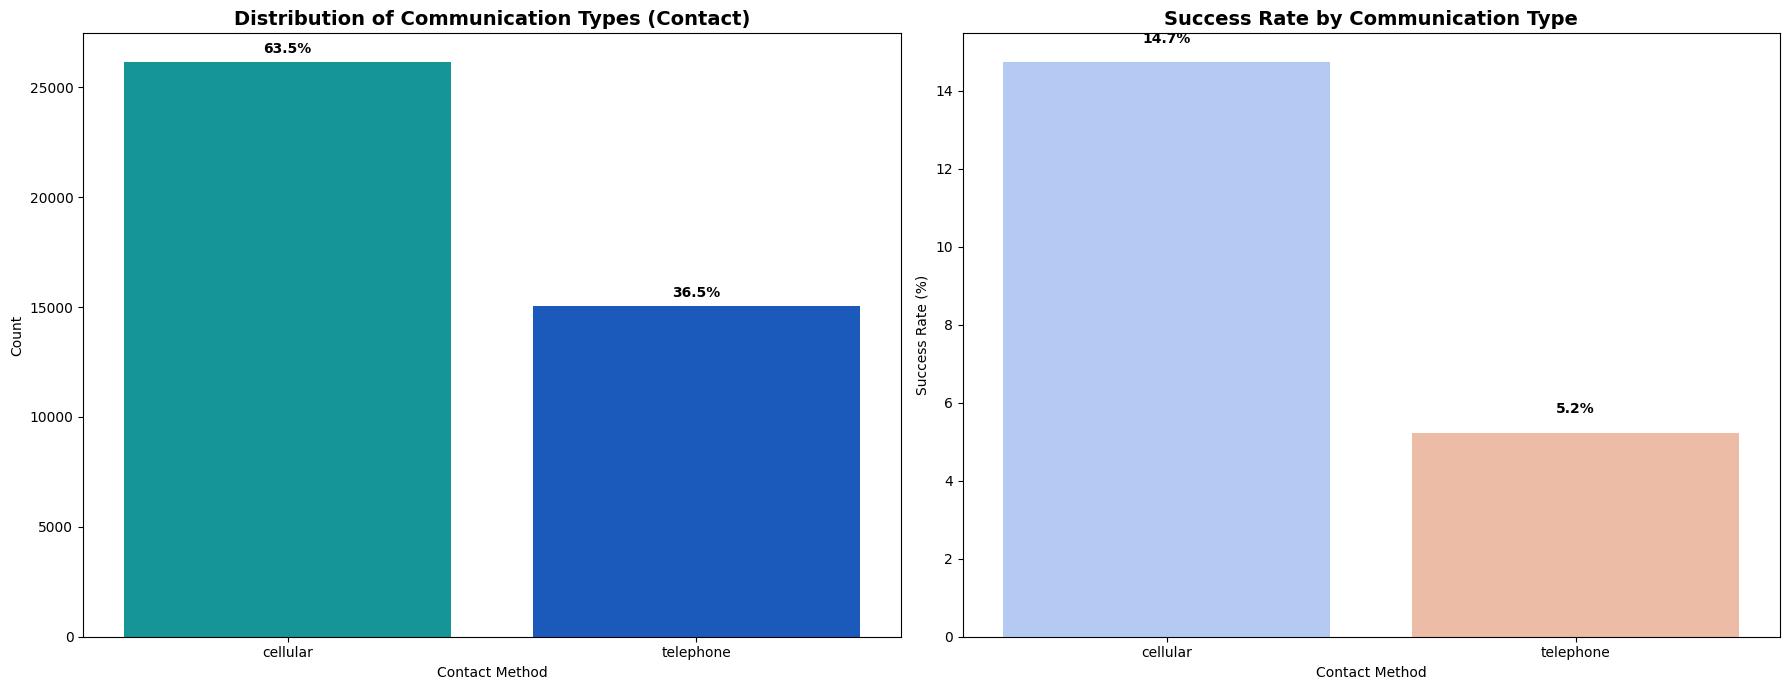

In [130]:
column = 'contact'

#Ensure the binary target exists for calculation
if 'target_binary' not in df_bank.columns:
    df_bank['target_binary'] = df_bank['y'].apply(lambda x: 1 if x == 'yes' else 0)

counts = df_bank[column].value_counts()
order = counts.index
total = len(df_bank)
success_stats = df_bank.groupby(column)['target_binary'].mean() * 100
success_stats = success_stats.reindex(order)

plt.figure(figsize=(18, 7))

#Distribution of Contact Types
plt.subplot(1, 2, 1)
sns.countplot(data=df_bank, x=column, order=order, palette='winter', hue=column, legend=False)
plt.title(f'Distribution of Communication Types ({column.capitalize()})', fontsize=14, fontweight='bold')
plt.xlabel('Contact Method')
plt.ylabel('Count')

for i, category in enumerate(order):
    count = counts[category]
    pct = (count / total) * 100
    plt.text(i, count + (total * 0.01), f'{pct:.1f}%', ha='center', fontweight='bold')

#Success Rate by Contact Type
plt.subplot(1, 2, 2)
sns.barplot(x=success_stats.index, y=success_stats.values, palette='coolwarm', hue=success_stats.index, legend=False)
plt.title(f'Success Rate by Communication Type', fontsize=14, fontweight='bold')
plt.xlabel('Contact Method')
plt.ylabel('Success Rate (%)')

for i, val in enumerate(success_stats.values):
    text_val = f'{val:.1f}%' if not np.isnan(val) else '0.0%'
    plt.text(i, (val if not np.isnan(val) else 0) + 0.5, text_val, ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Cellular make up about 63.5% of the data while telephone around 36.5%. With their success rate of cellular is 14.7% and telephone being 5.2%

Insight and wisdom:

It is very clear with around 9% different in success rate cellular is just a better way to contact a person. Cellular is a lot more flexible in usage so in turn make an easier communication method for a lot of people, while phone is awkward to use and might be less comfortable. So for the future campaign we should try to use cellular to contact a person as much as possible.

**Analysis for Month**

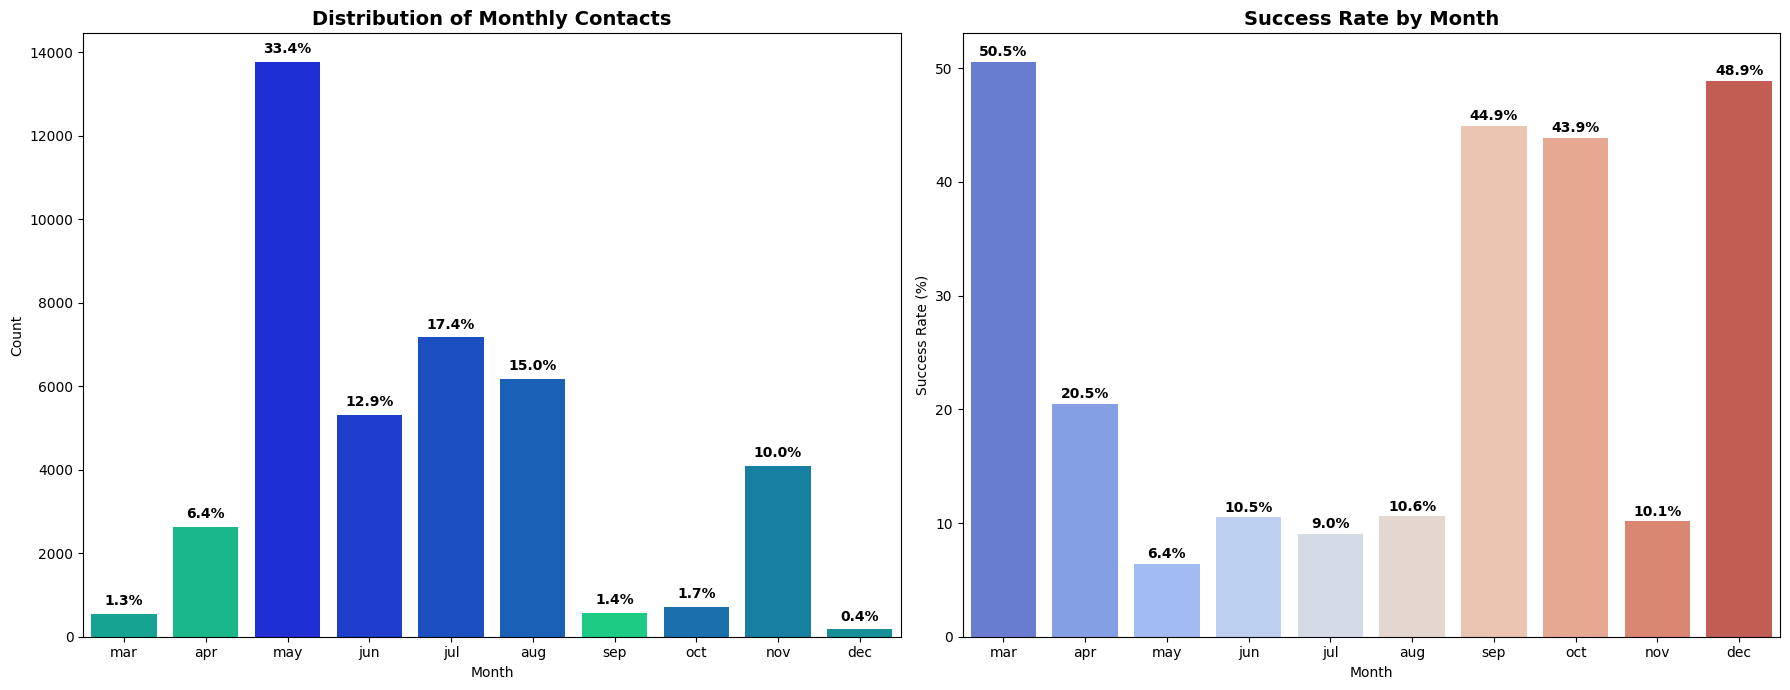

In [131]:
column = 'month'

if 'target_binary' not in df_bank.columns:
    df_bank['target_binary'] = df_bank['y'].apply(lambda x: 1 if x == 'yes' else 0)

#Define chronological order starting from March
month_order = [
    'mar', 'apr', 'may', 'jun', 'jul', 'aug', 
    'sep', 'oct', 'nov', 'dec']

#Ensure the month column is lowercase to match our list
df_bank['month'] = df_bank['month'].str.lower()

#Calculate statistics
counts = df_bank[column].value_counts().reindex(month_order).fillna(0)
total = len(df_bank)
#Calculate mean and multiply by 100 for percentage
success_stats = df_bank.groupby(column)['target_binary'].mean() * 100
success_stats = success_stats.reindex(month_order)

plt.figure(figsize=(18, 7))

#Distribution of Months
plt.subplot(1, 2, 1)
sns.countplot(data=df_bank, x=column, order=month_order, palette='winter', hue=column, legend=False)
plt.title(f'Distribution of Monthly Contacts', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Count')

for i, category in enumerate(month_order):
    count = counts[category]
    pct = (count / total) * 100
    plt.text(i, count + (total * 0.005), f'{pct:.1f}%', ha='center', fontweight='bold')

#Success Rate by Month
plt.subplot(1, 2, 2)
sns.barplot(x=success_stats.index, y=success_stats.values, palette='coolwarm', hue=success_stats.index, legend=False)
plt.title(f'Success Rate by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Success Rate (%)')

for i, val in enumerate(success_stats.values):
    text_val = f'{val:.1f}%' if not np.isnan(val) else '0.0%'
    plt.text(i, (val if not np.isnan(val) else 0) + 0.5, text_val, ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

We can see from the top 3 of distribution contact being may at 33.4% or around 13500 people followed by july at 17.4% and aug at 15%, at the bottom three is december, september and march with less than 1000 call during that time. For the success rate by month we see that march, december, september and october has the highest success rate at 50.5%, 48.9%, 44.9% and 43.9% respectively. While the lowest being may at 6.4% even though it has the highest call.

Insight and wisdom:

The likely reason why January and February were not included here is likely that bank has other objective instead of trying to meet target of the deposit like compiling the data they collected or the campaign call is only for 10 month period because of bank policies. We see in may the massive call even though it only has a 6.4% the likely reason is the bank is not prioritizing selecting their target properly (warm lead) and calling averyone as much as possible (cold lead), the same happen in june, july and august the likely reason is that they have some sort of mid-year targets so they call as much as possible. The other option is likely due to holiday season, this is europe data set (portugese) they are approaching holiday (summer) so bank worker tend to be more active before holiday season. But in the contrary when they only do selective call like in march, september, october and december the success rate fly as much as 43% to 50% which is impressive. So inconclusion, we should be pretty much becareful with who we want to do the call, do a proper research before calling the target so that what happen in may is not going to happen again. Instead we should recreate the scenario happening in march, september, october or december as much as possible.

**Analysis for Day of Week**

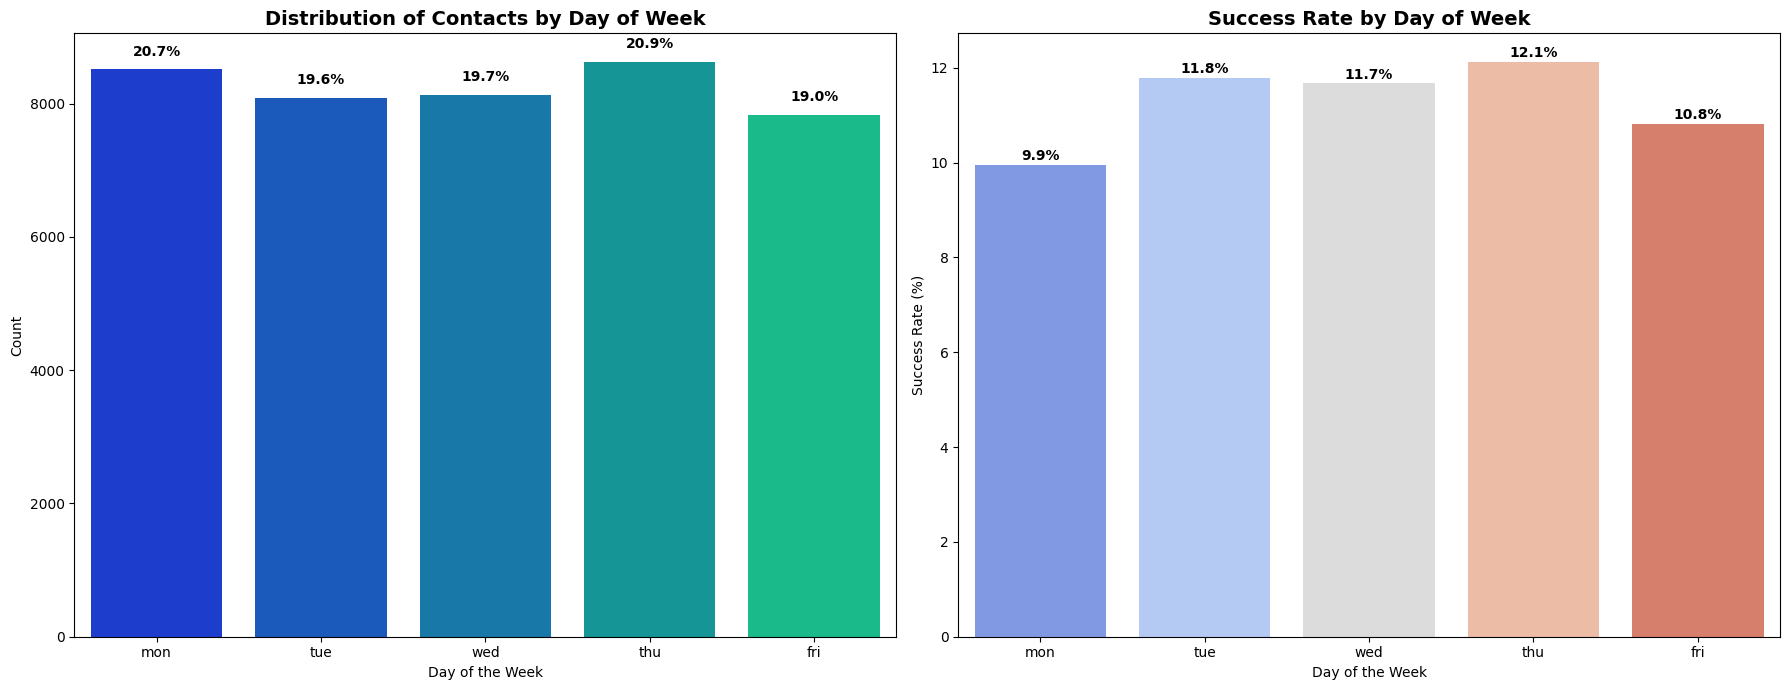

In [132]:
column = 'day_of_week'

if 'target_binary' not in df_bank.columns:
    df_bank['target_binary'] = df_bank['y'].apply(lambda x: 1 if x == 'yes' else 0)

#Define chronological order for work days
day_order = ['mon', 'tue', 'wed', 'thu', 'fri']

#Ensure lowercase for matching
df_bank[column] = df_bank[column].str.lower()

#Calculate statistics
counts = df_bank[column].value_counts().reindex(day_order).fillna(0)
total = len(df_bank)
success_stats = df_bank.groupby(column)['target_binary'].mean() * 100
success_stats = success_stats.reindex(day_order)

plt.figure(figsize=(18, 7))

#Distribution of Days
plt.subplot(1, 2, 1)
sns.countplot(data=df_bank, x=column, order=day_order, palette='winter', hue=column, legend=False)
plt.title(f'Distribution of Contacts by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of the Week')
plt.ylabel('Count')

for i, category in enumerate(day_order):
    count = counts[category]
    pct = (count / total) * 100
    plt.text(i, count + (total * 0.005), f'{pct:.1f}%', ha='center', fontweight='bold')

#Success Rate by Day
plt.subplot(1, 2, 2)
sns.barplot(x=success_stats.index, y=success_stats.values, palette='coolwarm', hue=success_stats.index, legend=False)
plt.title(f'Success Rate by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of the Week')
plt.ylabel('Success Rate (%)')

for i, val in enumerate(success_stats.values):
    text_val = f'{val:.1f}%' if not np.isnan(val) else '0.0%'
    plt.text(i, (val if not np.isnan(val) else 0) + 0.1, text_val, ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

From the chart we see that the call on all five days is about the same around 8000 calls with the lowes being on friday and the highest being on thursday. We see that monday has the lowest success rate of 9.9% compare to the other while thursday having the highest at 12.1%. Friday is the second lowest of 10.8%. The likely reason they don't do call on saturday and sunday is because they don't work during that time.

Insight and wisdom:

Even though there are not that much different in success rate we see that monday is the lowest and friday followed. The likely reason during monday people tend to be a lot more aggressive and down that after holiday they have to go to work on monday, while in friday they seems way more relaxed because holiday on saturday approaching. So based on these we should lowering the number of calls on monday and friday, instead increasing the campaign activity during tuesday, wednesday and thursday.

**Analysis for Duration**

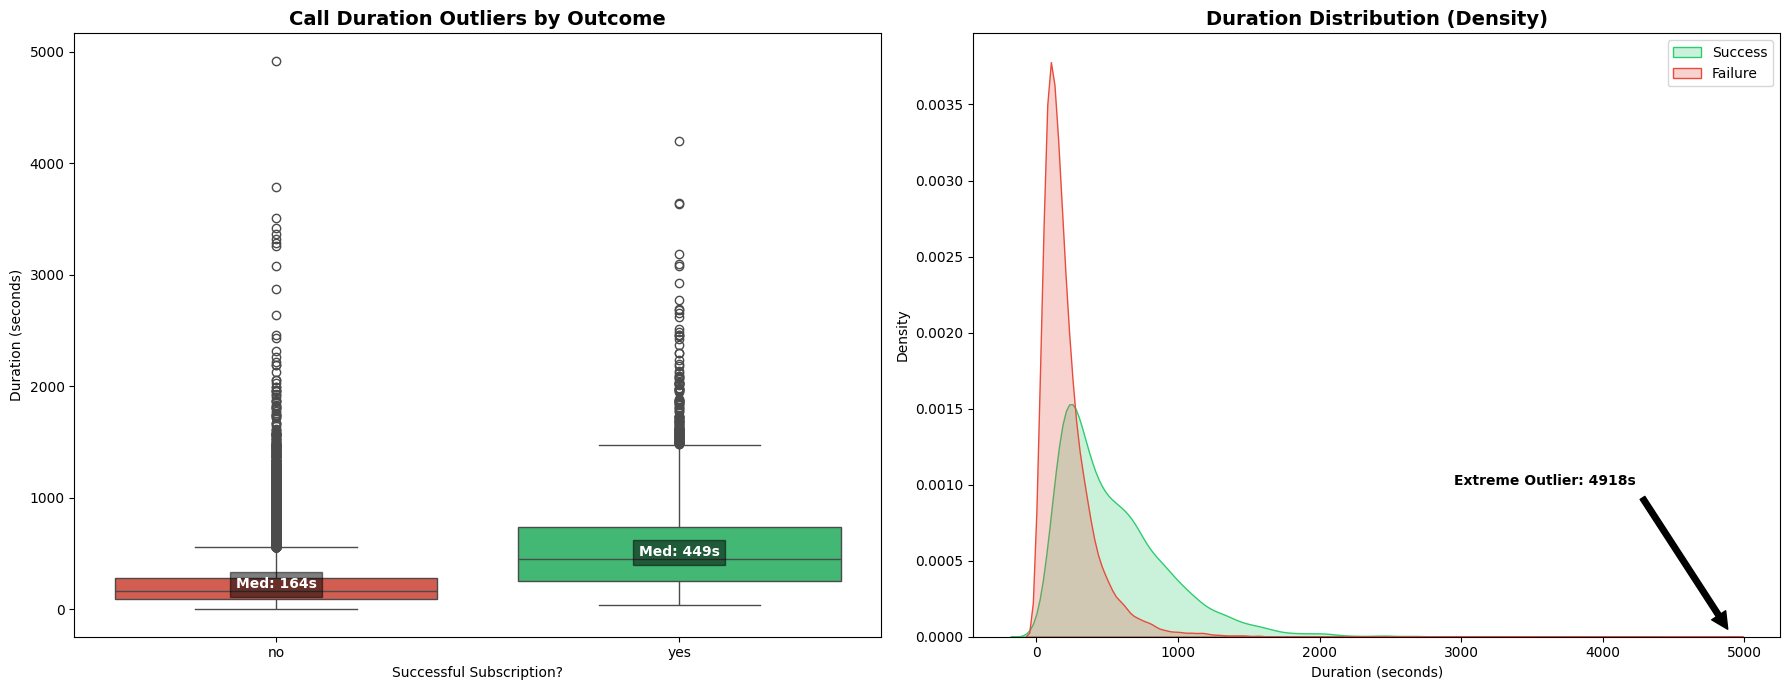

In [133]:
#Setup column and ensure target_binary exists
column = 'duration'

if 'target_binary' not in df_bank.columns:
    df_bank['target_binary'] = df_bank['y'].apply(lambda x: 1 if x == 'yes' else 0)

plt.figure(figsize=(18, 7))

#Boxplot to visualize Outliers
plt.subplot(1, 2, 1)
sns.boxplot(data=df_bank, x='y', y=column, palette={'yes': '#2ecc71', 'no': '#e74c3c'}, hue='y', legend=False)
plt.title('Call Duration Outliers by Outcome', fontsize=14, fontweight='bold')
plt.xlabel('Successful Subscription?')
plt.ylabel('Duration (seconds)')

#Statistical markers for the boxplot
for i, group in enumerate(['no', 'yes']):
    median = df_bank[df_bank['y'] == group][column].median()
    plt.text(i, median, f'Med: {median:.0f}s', ha='center', va='bottom', fontweight='bold', color='white', bbox=dict(facecolor='black', alpha=0.5))

#Distribution of Duration by Success
plt.subplot(1, 2, 2)
#We limit the x-axis for better visibility, but outliers are still in the data
sns.kdeplot(data=df_bank[df_bank['y'] == 'yes'], x=column, label='Success', fill=True, color='#2ecc71')
sns.kdeplot(data=df_bank[df_bank['y'] == 'no'], x=column, label='Failure', fill=True, color='#e74c3c')

plt.title('Duration Distribution (Density)', fontsize=14, fontweight='bold')
plt.xlabel('Duration (seconds)')
plt.ylabel('Density')
plt.legend()

#Adding an annotation about the outliers
max_val = df_bank[column].max()
plt.annotate(f'Extreme Outlier: {max_val}s', 
             xy=(max_val, 0), 
             xytext=(max_val*0.6, 0.001),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontweight='bold')

plt.tight_layout()
plt.show()

#Descriptive Stats for Outlier Reference
outlier_threshold = df_bank[column].mean() + 3 * df_bank[column].std()
outliers_count = len(df_bank[df_bank[column] > outlier_threshold])

Looking at the boxplot we see that the unsuccessful subscription (no) has a lower median of call duration being 164 second and the successful subscription (yes) has a higher median of call duration being 449 second. And we go to the kdeplot we see that the failure happen when the duration is lower with most call failed around 0 to 500 second, while the success happen when the duration is higher aroound 100 to 1000 second. There is an extreme outlier on 4918s, this is way too extreme for the data so we should remove it. Also additional note here, duration only happen once the call is performed, meaning if any of the call that has 0-10 second that resulted in failure should not be counted towards the modeling. And in reality when we about to call someone we cannot just say "hey, that customer is going to call for 10 minutes!", we just cannot predict that. So we should remove duration from the modeling.

Insight and wisdom:

Even though we don't use duration in modeling, there is still a lesson to learn here. Because the longer the call is the likely that someone would deposit, bank should prioritize training the employee to have the ability to keep up with longer conversation. The ability to convince more people to deposit, give them more option, insentive and promotion.

**Analysis for Campaign**

C:\Users\Diarra  Lenovo\AppData\Local\Temp\ipykernel_7764\1995555693.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_bank, x=target_name, y=column_name, palette='Set2')


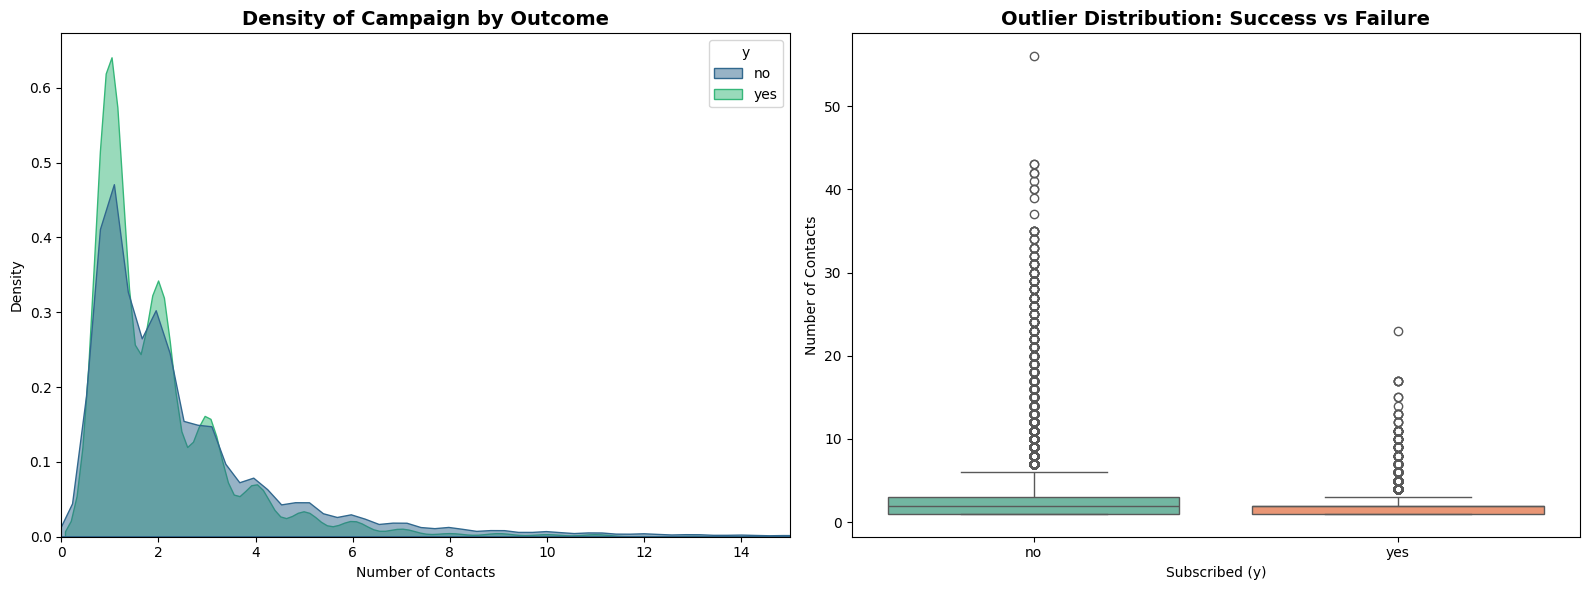

In [134]:
#Define target and feature
column_name = 'campaign'
target_name = 'y' # Assuming 'y' is the column for success/failure (yes/no)

#Prepare Plotting Area
plt.figure(figsize=(16, 6))

#KDE (Density) Plot
#This shows where the "mass" of successes vs failures lies
plt.subplot(1, 2, 1)
sns.kdeplot(data=df_bank, x=column_name, hue=target_name, fill=True, common_norm=False, palette='viridis', alpha=0.5)
plt.title(f'Density of {column_name.capitalize()} by Outcome', fontsize=14, fontweight='bold')
plt.xlabel('Number of Contacts')
plt.ylabel('Density')
plt.xlim(0, 15) # Zooming in to see the density clearly, as outliers stretch the axis

#Boxplot with Outliers
#This highlights the difference in outlier behavior between success and failure
plt.subplot(1, 2, 2)
sns.boxplot(data=df_bank, x=target_name, y=column_name, palette='Set2')
plt.title(f'Outlier Distribution: Success vs Failure', fontsize=14, fontweight='bold')
plt.xlabel('Subscribed (y)')
plt.ylabel('Number of Contacts')

plt.tight_layout()
plt.show()

"Campaign" shows how many time we contacts the potential customer before they say yes or no. We see that most campaign being decided after 2 calls, wether the customer say yes or no. We see that there is an outlier of above 50 calls, we should definitely remove that.

insight and wisdom:

If we look closer it seems that people that get called one, two and three time actually has a higher "yes" than people that being called more than 4 times. There are some reason for it, the caller is potentionally more convincing in their conversation with the customer, the less contact that happen the happier to deposit the customer should be. The reverse is happening with the "no", the more you contact someone the less likely they are going to say no, that might be because the caller is not convincing enough on their conversation or the potential depositor is much more dificult to convince. So the future solution should be to make sure that we train our caller to have a target that we should convince more costumer in less than 4 contact/campaign by giving them insentive, option and promotion.

**Analysis for Previous Days that was contacted before**

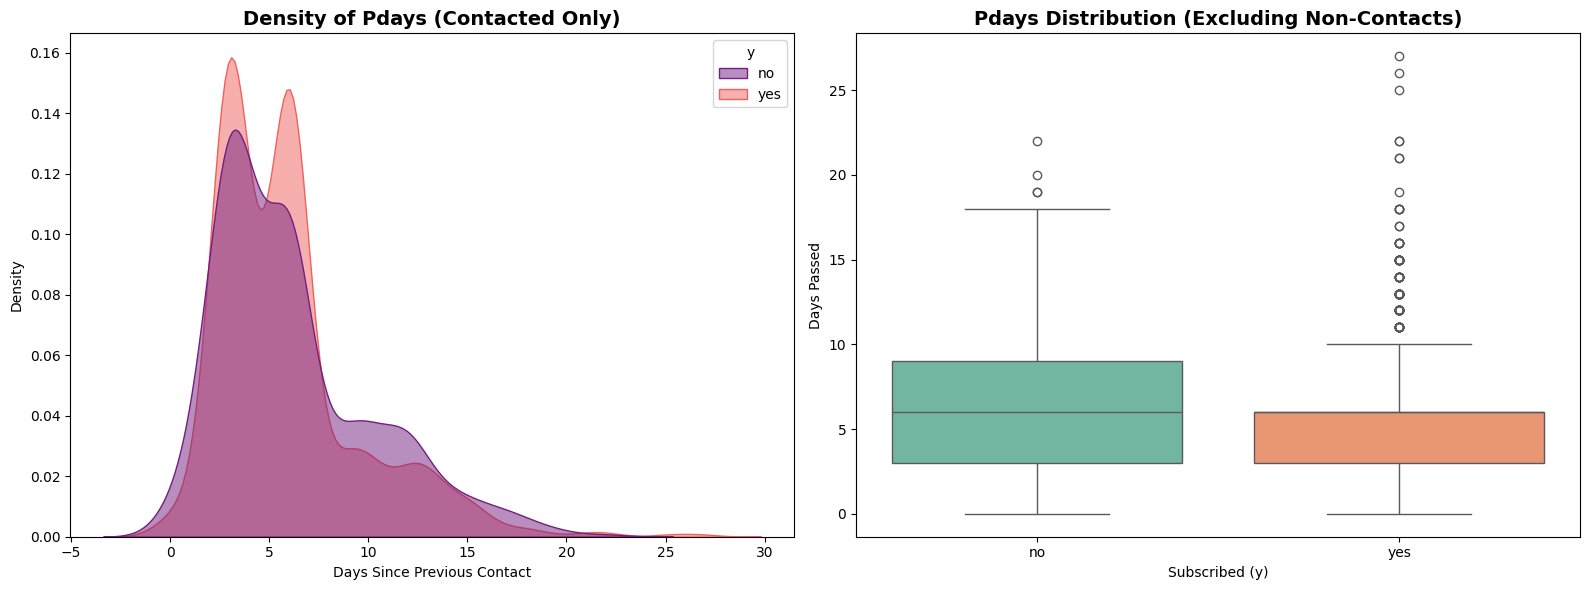

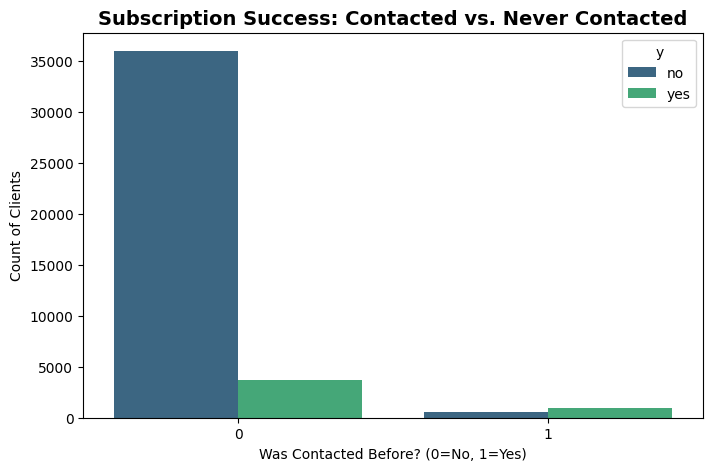

In [135]:
# efine variables
column_name = 'pdays'
target_name = 'y'

#Filter data: Only clients who were contacted before
#Based on your previous transformation, pdays > 0 or was_contacted_before == 1
df_contacted = df_bank[df_bank['was_contacted_before'] == 1].copy()

plt.figure(figsize=(16, 6))

#KDE (Density) Plot
plt.subplot(1, 2, 1)
sns.kdeplot(
    data=df_contacted, 
    x=column_name, 
    hue=target_name, 
    fill=True, 
    common_norm=False, 
    palette='magma', 
    alpha=0.5
)
plt.title(f'Density of {column_name.capitalize()} (Contacted Only)', fontsize=14, fontweight='bold')
plt.xlabel('Days Since Previous Contact')
plt.ylabel('Density')

#Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(
    data=df_contacted, 
    x=target_name, 
    y=column_name, 
    hue=target_name, 
    palette='Set2', 
    legend=False
)
plt.title(f'{column_name.capitalize()} Distribution (Excluding Non-Contacts)', fontsize=14, fontweight='bold')
plt.xlabel('Subscribed (y)')
plt.ylabel('Days Passed')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(data=df_bank, x='was_contacted_before', hue=target_name, palette='viridis')
plt.title('Subscription Success: Contacted vs. Never Contacted', fontsize=14, fontweight='bold')
plt.xlabel('Was Contacted Before? (0=No, 1=Yes)')
plt.ylabel('Count of Clients')
plt.show()

Pdays in this case is the number of days that passed by after the client was last contacted from a previous campaign. We can see from countplot most people "never even being called before or only contacted today" in the data, the number is quite high around 39000 people. While people that has been contacted more than a day is actually in the minority. While in the kde and boxplot because we exclude the people that has been contacted before we can see that customer been contacted most between 3 to 15 days.

Insight and wisdom:

People tend to be depositing after 3 to 7 days of last contacted, that is exactly the sweet spot for the client to say yes. meanwhile if we contacted them too early (<3 days) or too late (>7 days) they are more likely to not deposit.If it is too early that might be rude the client and if it too late than the brand awereness is likely faded. So we should prioritize the contacted after around 3 to 7 days of conversation to make sure they say "yes".



**Analysis for Previous Outcome**

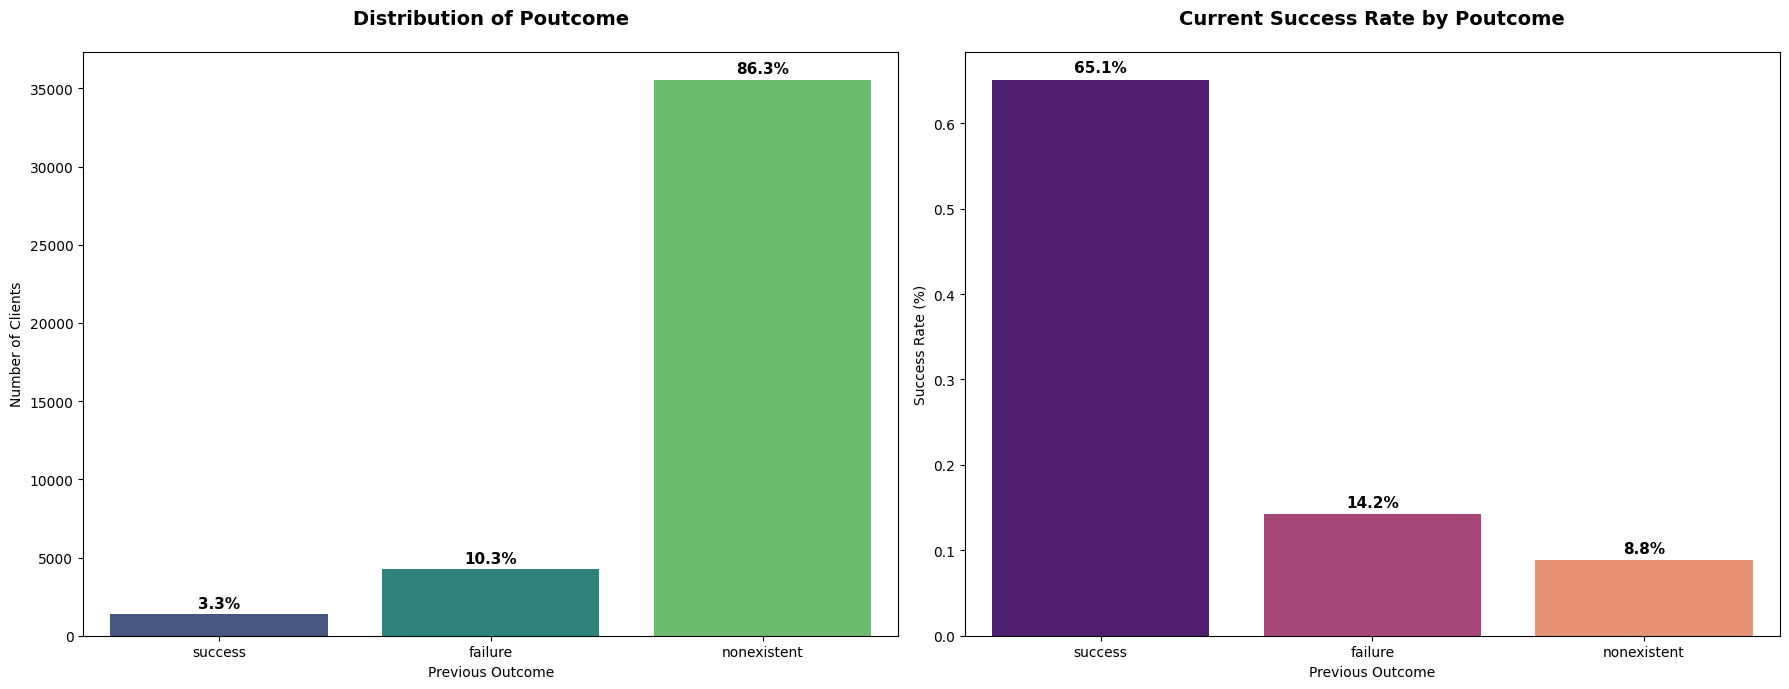

In [136]:
column = 'poutcome'

#Data Preparation
#Using target_binary directly and calculating stats
pout_stats = df_bank.groupby(column).agg({
    'target_binary': ['count', 'mean']
}).reset_index()

pout_stats.columns = [column, 'total_count', 'success_rate']

#Logic for ordering poutcome for better visual flow
pout_order = ['success', 'failure', 'nonexistent', 'other']
available_order = [p for p in pout_order if p in pout_stats[column].unique()]
pout_stats = pout_stats.set_index(column).reindex(available_order).reset_index()

#Calculate percentage of total for labels
total_clients = pout_stats['total_count'].sum()
pout_stats['percent_of_total'] = (pout_stats['total_count'] / total_clients)

plt.figure(figsize=(18, 7))

#Distribution (Volume)
plt.subplot(1, 2, 1)
sns.barplot(
    data=pout_stats, 
    x=column, 
    y='total_count', 
    palette='viridis',
    hue=column,
    legend=False
)
plt.title(f'Distribution of {column.capitalize()}', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Number of Clients')
plt.xlabel('Previous Outcome')

#Add percentage labels above volume bars
for i, row in pout_stats.iterrows():
    plt.text(i, row['total_count'] + (total_clients * 0.005), 
             f"{row['percent_of_total']:.1%}", 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

#Success Rate (The "Gold" Insight)
plt.subplot(1, 2, 2)
sns.barplot(
    data=pout_stats, 
    x=column, 
    y='success_rate', 
    palette='magma',
    hue=column,
    legend=False
)
plt.title(f'Current Success Rate by {column.capitalize()}', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Success Rate (%)')
plt.xlabel('Previous Outcome')

#Add percentage labels above success rate bars
for i, rate in enumerate(pout_stats['success_rate']):
    plt.text(i, rate + 0.005, f'{rate:.1%}', 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

Poutcome is Previous outcome that mean the outcome of the previous targeted campaign. We can see from the chart that success and failure combination total of 13.6% which is around 6500 peeople. That mean this 6500 people has been call before from the previous campaign. We can see from the boxplot that success is the lowest with 3.3% or around 1500 people while failure around 4000 people and the biggest margin which is nonexistent is 86.3% or around 35000 people. But when we see the success rate of success or the people that has already deposit beforehand the success rate is 65.1%, while the success rate of failure contact before is around 14.2%. And last but not least nonexistent success rate is 8.8%.

Insight and wisdom:

It make total sense that people that ever deposit before to bank (success) actually has higher success rate because their connection to the bank already deepen so that they likely deposit even more. but at the same time the bank tried to contact people in previous campaign that says no to try to convert them into saying yes, however only 14.2% ended up converting. They likely have too think twice before depositing because they already rejected it the first time, maybe because economic factor, family factor, etc. so that why they most likely reject it. While the people that never get contacted before (nonexistent) likely not many accepted because the bank is not entizing enough for them or somesort of individual factor. So the take away is for the next campaign we should prioritize the call on client that already has deposit to increase success rate in the future but we also has to keep in mind of the people that "almost" get converted so that we could potensially get them to deposit in the future.

**Analysis for Previous Contact**

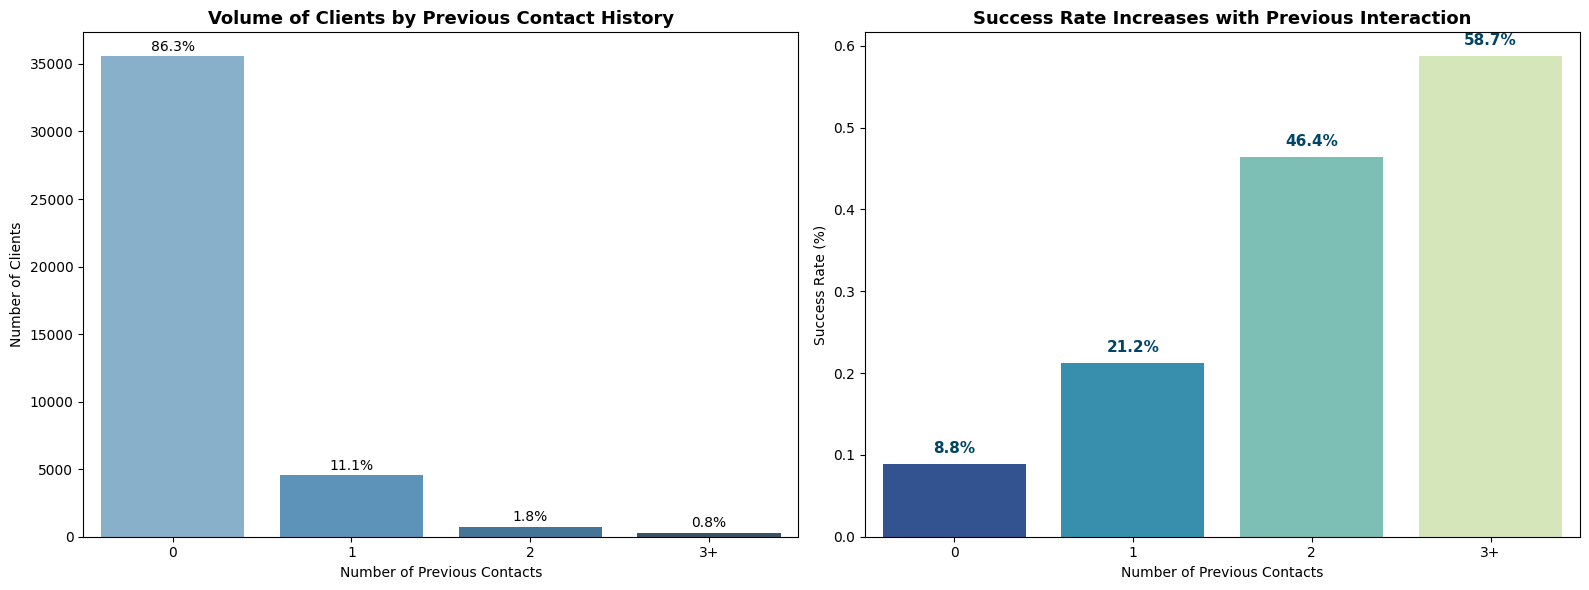

In [137]:
#Data Preparation
if 'target_binary' not in df_bank.columns:
    df_bank['target_binary'] = df_bank['y'].apply(lambda x: 1 if x == 'yes' else 0)

#Create a grouped version of 'previous'
#We keep 0, 1, 2 as they are, and group 3 or more into '3+'
df_bank['previous_grouped'] = df_bank['previous'].apply(lambda x: str(x) if x < 3 else '3+')

#Calculate counts and success rates based on grouped data
column = 'previous_grouped'
prev_stats = df_bank.groupby(column).agg({
    'target_binary': ['count', 'mean']
}).reset_index()

prev_stats.columns = [column, 'total_count', 'success_rate']

#Ensure the order is logical: 0, 1, 2, then 3+
prev_stats[column] = pd.Categorical(prev_stats[column], categories=['0', '1', '2', '3+'], ordered=True)
prev_stats = prev_stats.sort_values(column)

total_clients = prev_stats['total_count'].sum()
prev_stats['percent_of_total'] = (prev_stats['total_count'] / total_clients)

plt.figure(figsize=(16, 6))

#Distribution (Absolute Volume + % of Total)
plt.subplot(1, 2, 1)
sns.barplot(
    data=prev_stats, 
    x=column, 
    y='total_count', 
    palette='Blues_d',
    hue=column,
    legend=False
)
plt.title('Volume of Clients by Previous Contact History', fontsize=13, fontweight='bold')
plt.ylabel('Number of Clients')
plt.xlabel('Number of Previous Contacts')

#Add percentage labels
for i, row in enumerate(prev_stats.itertuples()):
    plt.text(i, row.total_count + (total_clients * 0.01), 
             f"{row.percent_of_total:.1%}", 
             ha='center', fontsize=10, color='black')

#Success Rate (The "Trend" Chart)
plt.subplot(1, 2, 2)
sns.barplot(
    data=prev_stats, 
    x=column, 
    y='success_rate', 
    palette='YlGnBu_r',
    hue=column,
    legend=False
)
plt.title('Success Rate Increases with Previous Interaction', fontsize=13, fontweight='bold')
plt.ylabel('Success Rate (%)')
plt.xlabel('Number of Previous Contacts')

for i, rate in enumerate(prev_stats['success_rate']):
    plt.text(i, rate + 0.01, f'{rate:.1%}', 
             ha='center', va='bottom', fontsize=11, fontweight='bold', color='#004466')

plt.tight_layout()
plt.show()

We can see the volume of the previous contacted client, we see 0 has the same amount of value as "nonexistent" in poutcome suggesting that it is the same thing or related. Mean while the client that contacted 1 time has 11.1% or around 5000 people. And 2 times at 1.8% and 3+ times at 0.8%. From the success rate we see that the highest success rate is actually the client that has contacted 3+ times being 58.7%, followed by contacted 2 times 21.2%, contacted 1 time being 21.2% and 0 time being 8.8%.

Insight and wisdom:

As we can see very clearly that the more we contact a person is the more likely they are about to deposit. While the 0 being low is because that's the first time we ever contacted that potential client. Even though we come to the conclusion that the person that get contacted more is likely to deposit more, we should also suggest that the caller or from the bank side need to be professional when trying to convince people to deposit, like know the time to call, doing research on the individual first and giving them the best deal. And make sure that they like to be call more than once because if we are not careful could be considered rude by client.

**Analysis for Heatmap**

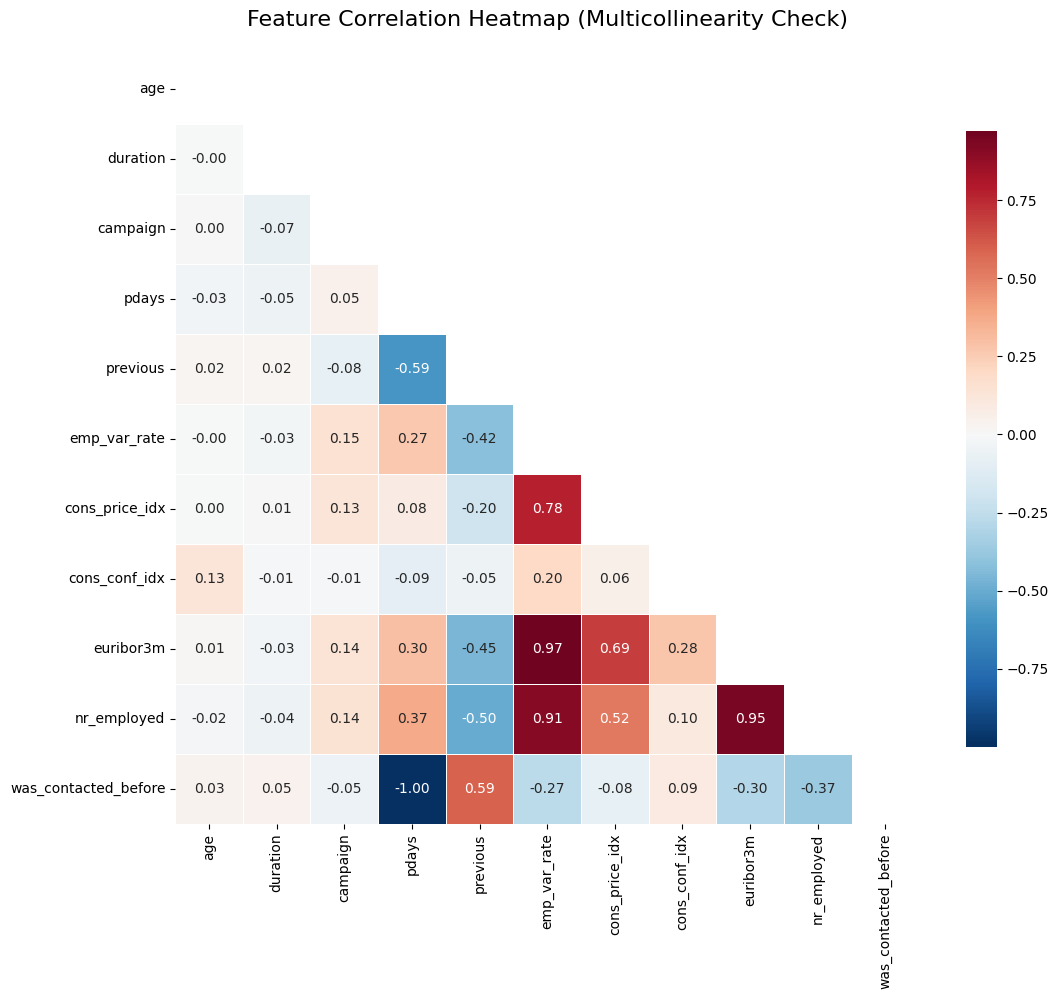

In [138]:
def generate_bank_heatmap_and_drop_list(df, target_cols=['y', 'target_binary']):
    """
    Generates a correlation heatmap and prints features to drop 
    based on high correlation (>0.9).
    """
    # 0. Work on a copy to avoid changing the original dataframe
    df_temp = df.copy()

    # 1. Prepare data: Drop all target columns and select only numeric features
    existing_targets = [col for col in target_cols if col in df_temp.columns]
    features_only = df_temp.drop(columns=existing_targets)
    
    # 2. Convert necessary columns to numeric if they are strings (like 'pdays')
    numeric_df = features_only.select_dtypes(include=[np.number])
    
    # 3. Calculate Correlation Matrix
    corr_matrix = numeric_df.corr()
    
    # --- NEW: Identify Features to Drop ---
    # Create a mask for the upper triangle
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # 4. Generate Heatmap
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    sns.heatmap(
        corr_matrix, 
        mask=mask, 
        annot=True, 
        fmt=".2f", 
        cmap='RdBu_r', 
        center=0,
        linewidths=.5, 
        cbar_kws={"shrink": .8}
    )
    
    plt.title('Feature Correlation Heatmap (Multicollinearity Check)', fontsize=16, pad=20)
    plt.show()

# Run the function on your dataframe
generate_bank_heatmap_and_drop_list(df_bank)

Before we move on to the economic indicator, we should see the heatmap first.

* Now we look at the super high correlation above 90%, we see that eribor3m, nr_empoyed and emp_var_rate has more than 90% threshold meaning that they tell the same story.

**Analysis for Employment Variation Rate**

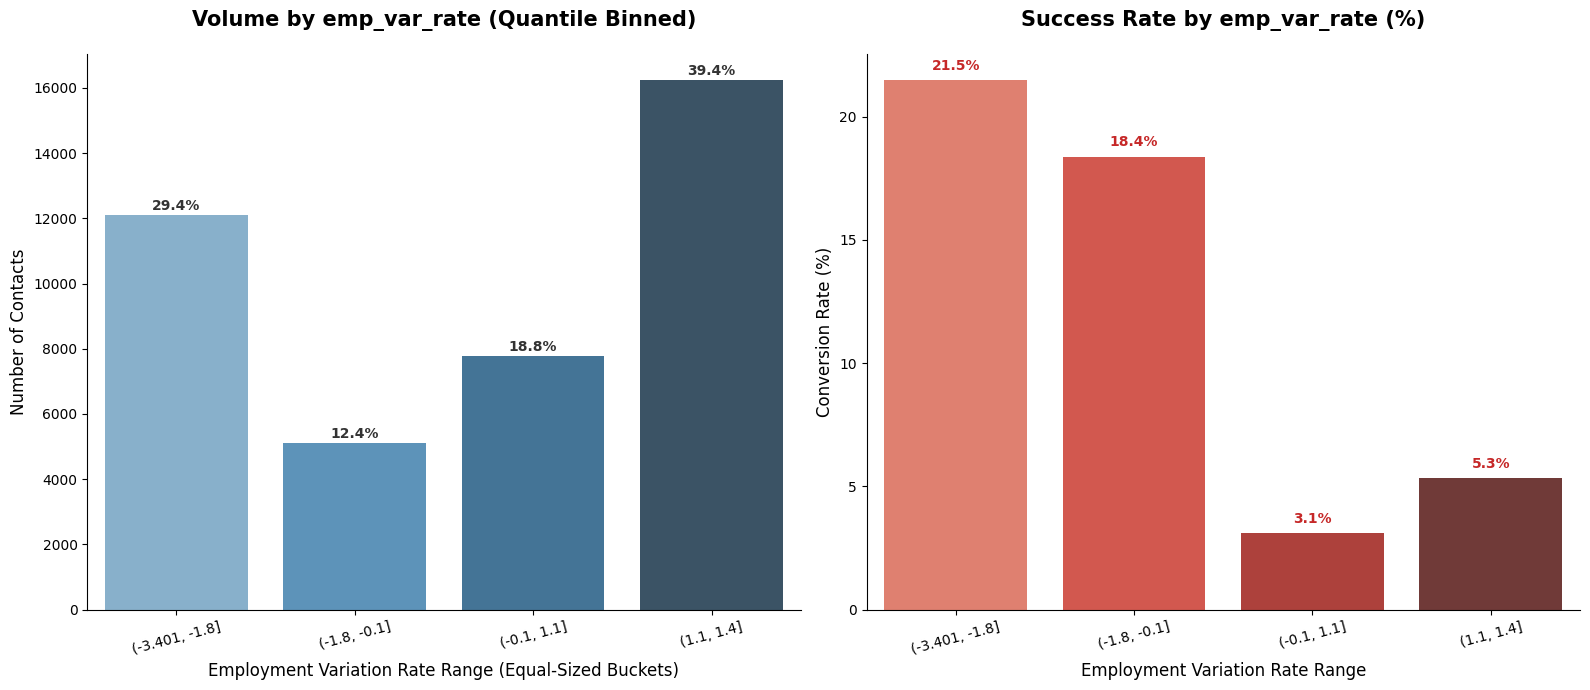

In [139]:
#Configuration - Focused on 'emp_var_rate'
column_econ = 'emp_var_rate' 

#Pre-processing (Ensuring target_binary exists)
if 'target_binary' not in df_bank.columns:
    df_bank['target_binary'] = df_bank['y'].apply(lambda x: 1 if x == 'yes' else 0)

#duplicates='drop' is used because economic rates often have many identical values
df_temp = df_bank.copy()
df_temp['emp_bins'] = pd.qcut(df_temp[column_econ], q=5, duplicates='drop')
column_cat = 'emp_bins'

#Calculate stats for ordering and labeling
counts = df_temp[column_cat].value_counts()
order = counts.index.sort_values() # Sorted numerically for economic logic
total = len(df_temp)
success_stats = df_temp.groupby(column_cat, observed=True)['target_binary'].mean() * 100
success_stats = success_stats.reindex(order)

plt.figure(figsize=(16, 7))

#Frequency Distribution (Volume is now balanced)
plt.subplot(1, 2, 1)
sns.countplot(
    data=df_temp, 
    x=column_cat, 
    order=order, 
    palette='Blues_d', 
    hue=column_cat, 
    legend=False
)
plt.title(f'Volume by {column_econ} (Quantile Binned)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Employment Variation Rate Range (Equal-Sized Buckets)', fontsize=12)
plt.ylabel('Number of Contacts', fontsize=12)
plt.xticks(rotation=15)

#Add percentage labels above bars
for i, category in enumerate(order):
    count = counts[category]
    pct = (count / total) * 100
    plt.text(i, count + (max(counts) * 0.01), f'{pct:.1f}%', ha='center', fontweight='bold', color='#333')

#Success Rate (Comparison is now more reliable)
plt.subplot(1, 2, 2)
sns.barplot(
    x=success_stats.index, 
    y=success_stats.values, 
    palette='Reds_d', 
    hue=success_stats.index, 
    legend=False
)
plt.title(f'Success Rate by {column_econ} (%)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Employment Variation Rate Range', fontsize=12)
plt.ylabel('Conversion Rate (%)', fontsize=12)
plt.xticks(rotation=15)

for i, val in enumerate(success_stats.values):
    text_val = f'{val:.1f}%' if not np.isnan(val) else '0.0%'
    plt.text(i, val + (max(success_stats) * 0.02), text_val, ha='center', fontweight='bold', color='#c62828')

sns.despine()
plt.tight_layout()
plt.show()

In order to look closely into the emp_var_rate we are using quantile bins to see a better visualization. The way we read it is that the lower the value the more decreasing the number of people being employed (-3.4 to -1.8) while the higher the value the more increasing the number of people being employed (1.1 to 1.4). As we can see the highest volume of call happen to be 1.1 to 1.4 of 39.4% or around 16000 people, and number 2 being -3.4 to -1.8 of 29.4% or around 12000 people. While the third being -0.1 to 1.1 of 18.8% or around 8000 people and the last is -1.8 to -0.1 with 12.4% or around 5000 people. If we look at the success rate the highest being -3.4 to -1.8 of 21.5% followed by -1.8 to -0.1 of 18.4%, the third is 1.1 to 1.4 of 5.3% and the last -0.1 to 1.1 of 3.1%.

Insight and wisdom:

The employment variation rate show us during the time people struggle (when emp_var_rate is low) people tend to deposit more often, this indicate that during this period bank offered a good deal to people or the people has a lot more value when they try to deposit. While the reverse is also true during the time people has more jobs (when emp_var_rate is higher) people tend to reject bank offer of deposit, the reason likely bank is not providing a good enough deal to people or people has more option to invest in a better deal than depositing at the bank. Because this is economic indicator we cannot for centain know what's going directly on the ground (economic crisis, financial issue), however if we are the bank what we should do is offer a better deal when the employent rate is higher so that more people is likely to deposit, refining strategy and learning about why other investment is better than depositing to the bank now. Don't forget to do indivual research before calling them.

**Analysis for Consumer Price Index**

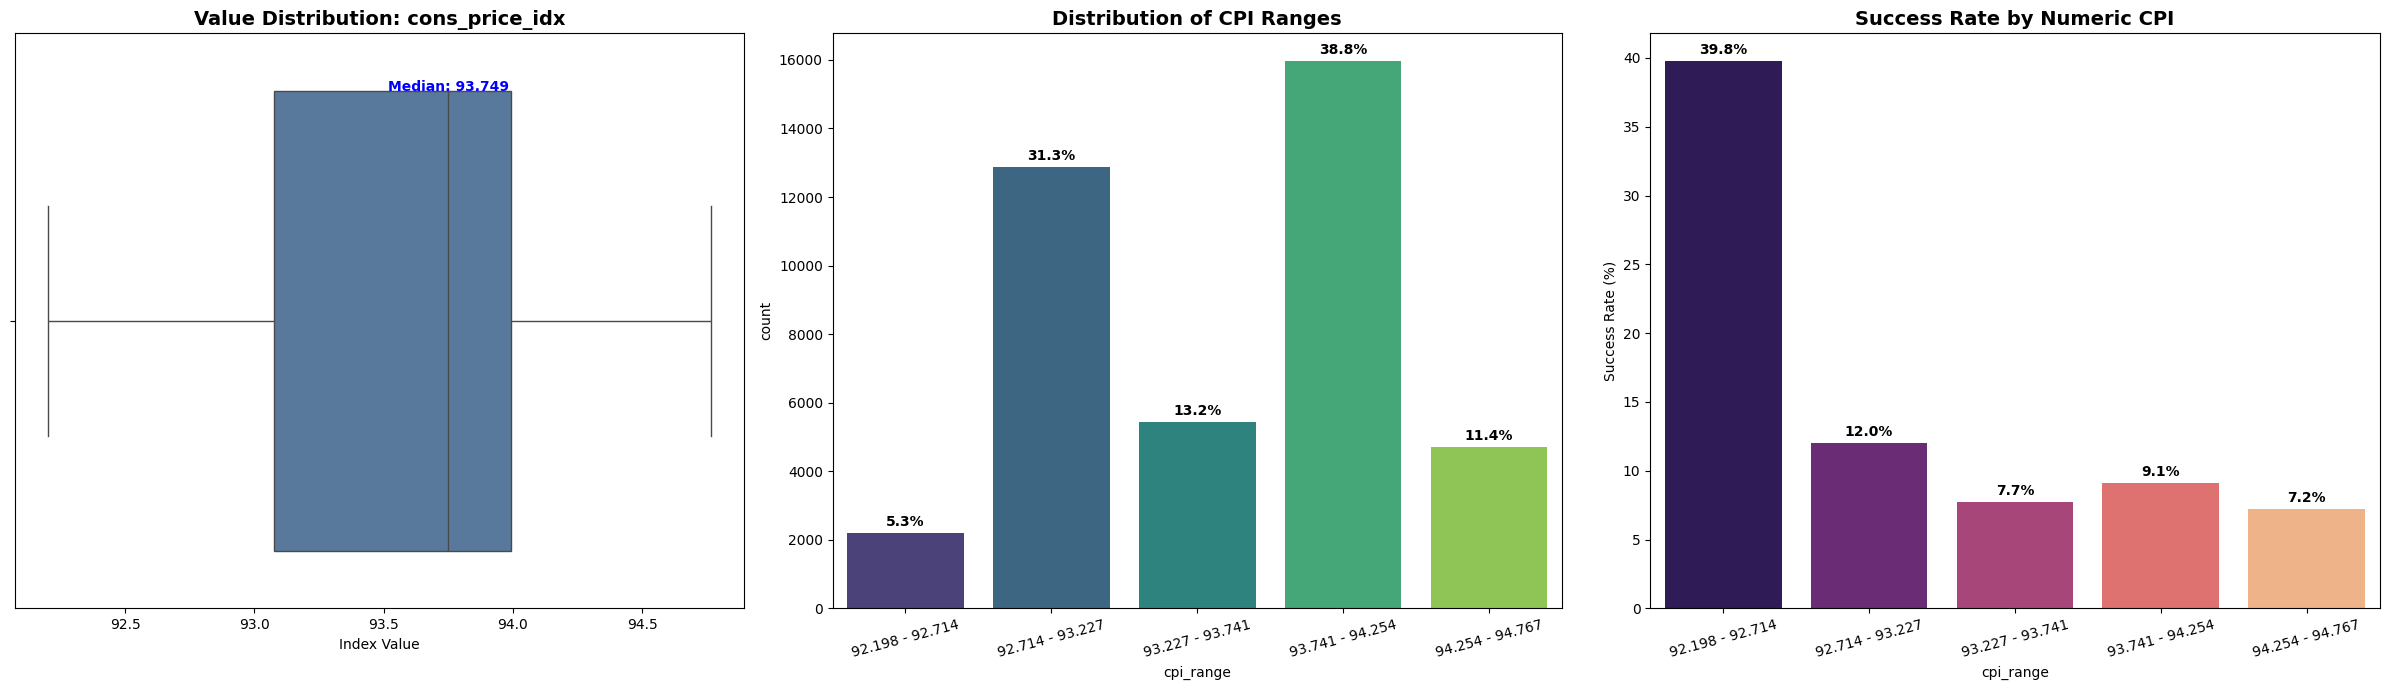

In [140]:
column_numeric = 'cons_price_idx'
column_cat = 'cpi_range'

#Setup Binary Target
if 'target_binary' not in df_bank.columns:
    df_bank['target_binary'] = df_bank['y'].apply(lambda x: 1 if x == 'yes' else 0)

#Dynamic Numeric Binning
#We create 5 equal-width numeric bins across the actual range of the data
min_val = df_bank[column_numeric].min()
max_val = df_bank[column_numeric].max()
#Using 5 bins to keep the chart readable while showing granularity
df_bank[column_cat] = pd.cut(df_bank[column_numeric], bins=5)

#Extract the interval labels for consistent ordering
labels = sorted(df_bank[column_cat].unique().dropna())
label_strings = [f"{str(i.left)} - {str(i.right)}" for i in labels]

#Prepare data for plotting
counts = df_bank[column_cat].value_counts().sort_index()
total = len(df_bank)
success_stats = df_bank.groupby(column_cat, observed=True)['target_binary'].mean() * 100

plt.figure(figsize=(24, 7))

#Outlier Detection
plt.subplot(1, 3, 1)
sns.boxplot(x=df_bank[column_numeric], color='#4e79a7')
plt.title(f'Value Distribution: {column_numeric}', fontsize=14, fontweight='bold')
plt.xlabel('Index Value')
median_val = df_bank[column_numeric].median()
plt.text(median_val, -0.4, f'Median: {median_val:.3f}', ha='center', color='blue', fontweight='bold')

#Frequency of Index Values
plt.subplot(1, 3, 2)
sns.countplot(data=df_bank, x=column_cat, palette='viridis', hue=column_cat, legend=False)
plt.title('Distribution of CPI Ranges', fontsize=14, fontweight='bold')
plt.xticks(range(len(label_strings)), label_strings, rotation=15)
for i, val in enumerate(counts):
    pct = (val / total) * 100
    plt.text(i, val + (total * 0.005), f'{pct:.1f}%', ha='center', fontweight='bold')

#Success Rate per Index Range
plt.subplot(1, 3, 3)
sns.barplot(x=success_stats.index, y=success_stats.values, palette='magma', hue=success_stats.index, legend=False)
plt.title('Success Rate by Numeric CPI', fontsize=14, fontweight='bold')
plt.ylabel('Success Rate (%)')
plt.xticks(range(len(label_strings)), label_strings, rotation=15)
for i, val in enumerate(success_stats.values):
    text_val = f'{val:.1f}%' if not np.isnan(val) else '0.0%'
    plt.text(i, (val if not np.isnan(val) else 0) + 0.5, text_val, ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

We can look at the call distribution it's spread across with 93.7 to 94.2 is the highest with 38.8% around 16000 people followed second by 92.7 to 93.2 of 31.3% or around 13000 people. The third 93.2 to 93.7 of 13.2% or around 5000 people, the forth is 94.2 to 94.7 of 11.4% or around 4500 people and lastly 92.1 to 92.7 of 5.3% or around 2000 people. We look at the success rate the most successful is 92.1 to 92.7 with 39.8% followed by 92.7 to 93.2 with 12%, the third being 93.7 to 94.2 with 9.1%, the forth is 93.2 to 93.7 with 7.7% and lastly 94.2 to 94.7 with 7.2%.

Insight and wisdom:

CPI is an indicator of inflation meaning the higher it gets the higher the price of goods is. As we can see the bank try to do their campaign effort during the most during 93.7 to 94.2 but the success rate is only 9.1% this mean the CPI is quite high at the time and people think depositing at the bank is not the best move yet and people likely has other plan with their money, the same goes when the CPI at 92.7 to 94.7. However we see a big spike in success rate during 92.1 to 92.7, even though bank doesn't do their campaign during this time people just happen to deposit that means during that time (lower CPI) is a perfect time to deposit for a lot of people. This is indicator of economics issue in display it doesn't matter if bank is going to do campaign or not if the right time to deposit is going to happen, people is going to deposit anyway. So what we should do if we are the bank, make sure to notice right away about the economic trend that happen on the ground if we see that the CPI is dropping we should launch our campaign, make sure to reduce the campaign if the CPI trend goes a lot more than expected. 

**Analysis for Consumer Confidence Index**

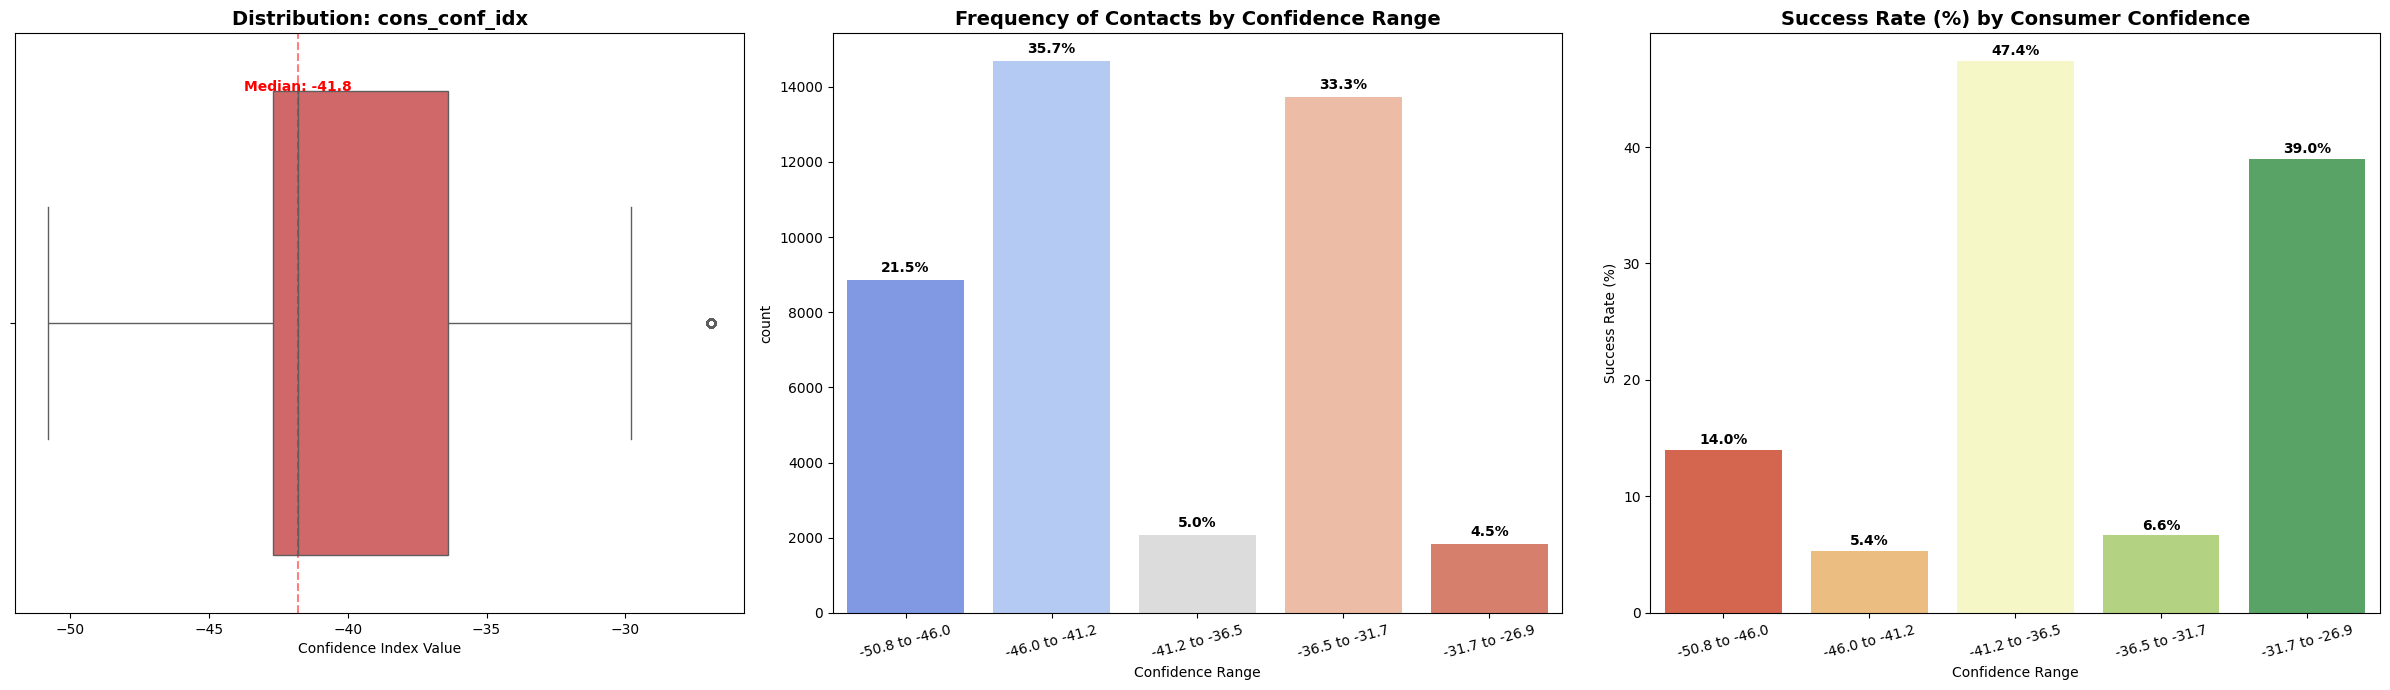

In [141]:
column_numeric = 'cons_conf_idx'
column_cat = 'conf_range'

#Setup Binary Target
if 'target_binary' not in df_bank.columns:
    df_bank['target_binary'] = df_bank['y'].apply(lambda x: 1 if x == 'yes' else 0)

#Dynamic Numeric Binning
#Cons. Conf. Index is typically negative (e.g., -50 to -20)
#We create 5 equal-width numeric bins to show the scale
df_bank[column_cat] = pd.cut(df_bank[column_numeric], bins=5)

#Extract and format the interval labels for the X-axis
labels = sorted(df_bank[column_cat].unique().dropna())
label_strings = [f"{float(i.left):.1f} to {float(i.right):.1f}" for i in labels]

#Prepare data for statistics
counts = df_bank[column_cat].value_counts().sort_index()
total = len(df_bank)
success_stats = df_bank.groupby(column_cat, observed=True)['target_binary'].mean() * 100

plt.figure(figsize=(24, 7))

#Outlier and Spread Analysis
plt.subplot(1, 3, 1)
sns.boxplot(x=df_bank[column_numeric], color='#e15759')
plt.title(f'Distribution: {column_numeric}', fontsize=14, fontweight='bold')
plt.xlabel('Confidence Index Value')
median_val = df_bank[column_numeric].median()
plt.axvline(median_val, color='red', linestyle='--', alpha=0.5)
plt.text(median_val, -0.4, f'Median: {median_val:.1f}', ha='center', color='red', fontweight='bold')

#Volume of Contacts per Confidence Level
plt.subplot(1, 3, 2)
sns.countplot(data=df_bank, x=column_cat, palette='coolwarm', hue=column_cat, legend=False)
plt.title('Frequency of Contacts by Confidence Range', fontsize=14, fontweight='bold')
plt.xticks(range(len(label_strings)), label_strings, rotation=15)
plt.xlabel('Confidence Range')
for i, val in enumerate(counts):
    pct = (val / total) * 100
    plt.text(i, val + (total * 0.005), f'{pct:.1f}%', ha='center', fontweight='bold')

#Conversion Rate vs Confidence
plt.subplot(1, 3, 3)
sns.barplot(x=success_stats.index, y=success_stats.values, palette='RdYlGn', hue=success_stats.index, legend=False)
plt.title('Success Rate (%) by Consumer Confidence', fontsize=14, fontweight='bold')
plt.ylabel('Success Rate (%)')
plt.xticks(range(len(label_strings)), label_strings, rotation=15)
plt.xlabel('Confidence Range')
for i, val in enumerate(success_stats.values):
    text_val = f'{val:.1f}%' if not np.isnan(val) else '0.0%'
    plt.text(i, (val if not np.isnan(val) else 0) + 0.5, text_val, ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

We can see from the plot that the highest contact by cons_conf_idx is -46 to -41.2 of 35.7% or around 15000 people, followed second by -36.5 to -31.7 of 33.3% or around 14000 people and the third is -50.8 to -46.0 of 21.5% or around 9000 people. And the lowest call frequency is -31.7 to -26.9 or around 1800 people and the forth is -41.2 to -36.5 or around 2000 people. The highest success rate by cci is -41.2 to -36.5 at 47.4%, second is -31.7 to -26.9 at 39%, third -50.8 to -46.0 at 14%, forth -36.5 to-31.7 at 6.6% and the last is -46 to 41.2 at 5.4%.

Insight and wisdom:

cons_conf_idx or cci is an indication of how a consumer behave the lower it get the more pessimistic the consumer get to the economy. And this indicator is driven by people emotion or psychology which mean is often goes up and down fast. As we can see during -31.7 to -26.9 even though bank campaign is not maximal the conversion rate is quite high, and then in -36.5 to 31.7 the success rate is lowering again to 6.6% and then it's high again (47.4%), then it's low again down to 5.4% even though during this time -46 to -41.2 the bank is on the campaign spree. However if you look closer bank did big campaign again during -50.6 to -46.0 and people actually want to deposit higher this time. Cci is an interesting indicator but sometimes because it's updating every month bank could miss a potential indicator that shows people want to deposit or not. If we were the bank we should also look into people behaviour to know are they currently on spending spree (-36.5 to 31.7 and -4.6 to 41.2), in the saving spree (-36.5 to 31.7 and -46 to 41.2) or force to saving (-50.8 to 46.0) and we should launch campaign during the time people likely want to save more and do deposit. 

**Analysis for Euribor 3 Month**

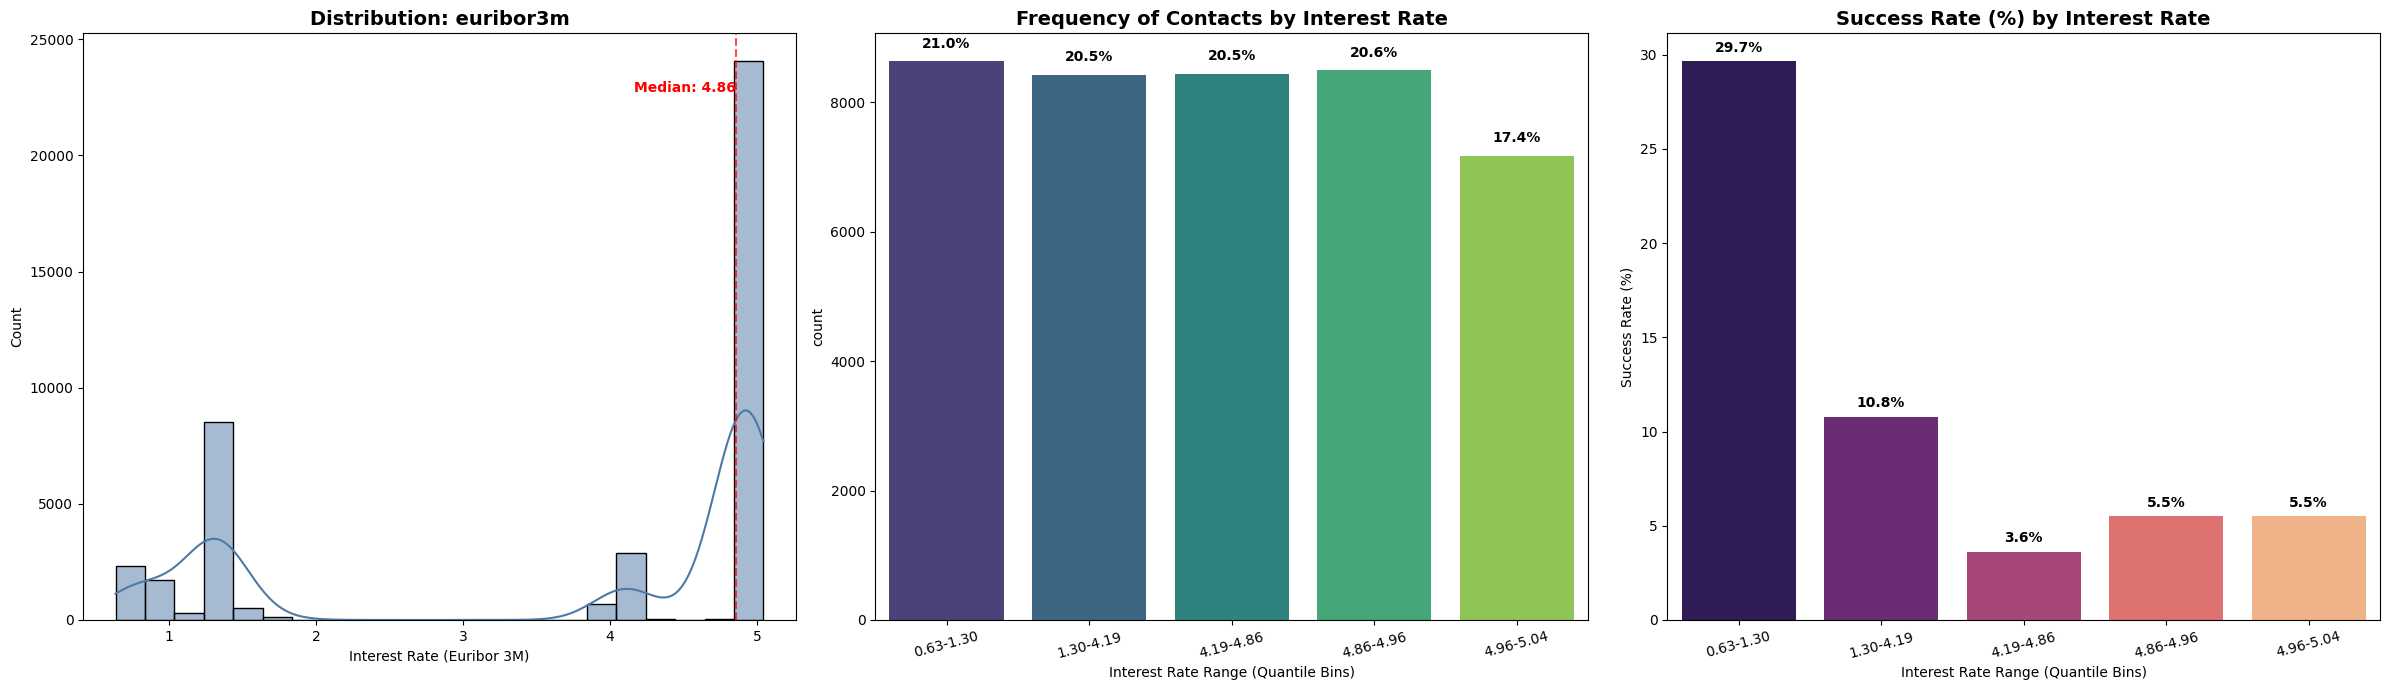

In [142]:
column_numeric = 'euribor3m'
column_cat = 'euribor_range'

#Setup Binary Target if not present
if 'target_binary' not in df_bank.columns:
    df_bank['target_binary'] = df_bank['y'].apply(lambda x: 1 if x == 'yes' else 0)

#Dynamic Numeric Binning
#Using qcut (Quantiles) instead of cut (Equal Width).
#This ensures each bin has roughly 20% of the total population, 
#forcing outliers to merge with their nearest neighbors.
try:
    # duplicates='drop' is a safety measure in case many values are identical
    df_bank[column_cat] = pd.qcut(df_bank[column_numeric], q=5, duplicates='drop')
except ValueError:
    # Fallback to fewer bins if the distribution is extremely skewed
    df_bank[column_cat] = pd.qcut(df_bank[column_numeric], q=3, duplicates='drop')

#Extract and format the interval labels for the X-axis
labels = sorted(df_bank[column_cat].unique().dropna())
label_strings = [f"{float(i.left):.2f}-{float(i.right):.2f}" for i in labels]

#Prepare stats
counts = df_bank[column_cat].value_counts().sort_index()
total = len(df_bank)
success_stats = df_bank.groupby(column_cat, observed=True)['target_binary'].mean() * 100

plt.figure(figsize=(24, 7))

#Density and Distribution
plt.subplot(1, 3, 1)
sns.histplot(df_bank[column_numeric], kde=True, color='#4e79a7')
plt.title(f'Distribution: {column_numeric}', fontsize=14, fontweight='bold')
plt.xlabel('Interest Rate (Euribor 3M)')
median_val = df_bank[column_numeric].median()
plt.axvline(median_val, color='red', linestyle='--', alpha=0.7)
plt.text(median_val, plt.ylim()[1]*0.9, f'Median: {median_val:.2f}', color='red', fontweight='bold', ha='right')

#Volume of Contacts per Interest Level
plt.subplot(1, 3, 2)
sns.countplot(data=df_bank, x=column_cat, palette='viridis', hue=column_cat, legend=False)
plt.title('Frequency of Contacts by Interest Rate', fontsize=14, fontweight='bold')
plt.xticks(range(len(label_strings)), label_strings, rotation=15)
plt.xlabel('Interest Rate Range (Quantile Bins)')
for i, val in enumerate(counts):
    pct = (val / total) * 100
    plt.text(i, val + (total * 0.005), f'{pct:.1f}%', ha='center', fontweight='bold')

#Conversion Rate vs Interest Rates
plt.subplot(1, 3, 3)
sns.barplot(x=success_stats.index, y=success_stats.values, palette='magma', hue=success_stats.index, legend=False)
plt.title('Success Rate (%) by Interest Rate', fontsize=14, fontweight='bold')
plt.ylabel('Success Rate (%)')
plt.xticks(range(len(label_strings)), label_strings, rotation=15)
plt.xlabel('Interest Rate Range (Quantile Bins)')
for i, val in enumerate(success_stats.values):
    text_val = f'{val:.1f}%' if not np.isnan(val) else '0.0%'
    plt.text(i, (val if not np.isnan(val) else 0) + 0.5, text_val, ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

To make it looks consistent we made the frequency of contact by interest rate using qcut too see the change on quantile bins compare to the histplot and if we look the countplot the different of gap is massive it divided into 0.63%-1.3% of around 8000 people or around 21%, 1.3%-4.19% of around 8000 people or around 20.5% this is a massive gap something must be happening here. Followed by 4.19-4.86 of around 8000 people or around 20.5%, and then 4.86%-4.96% around 8000 people or around 20.6% and 4.96%-5.04% around 7000 people or around 17.4%. The last two most likely where the bank campaign is at it's peak. And if we look at success rate 0.63%-1.3% at 29.7%, 1.3-4.19 at 10.8%, 4.86%-4.96% at 5.5%, 4.96%-5.04% at 5.5% as well and last 4.19-4.86 at 3.6%.

Insight and wisdom:

First let's look at the massive gap of the qcut of 1.3%-4.19% it seems that the interest rate just "blink" from around 3.5% interest immediately to below 2% (look at histplot), something of economical disaster must have happen here for the bank to just cut interest rate by this much it's not a normal sign. If we look at the success rate the bank campaign happening around 4.86%-5.04% only 5.5% of success rate and then during 4.19%-4.86% it's even lower to only 3.6%. But then you look when the bank decided to lower interest rate and the campaign start again during 0.63%-1.3% the success rate is skyrocket, the likely reason is probably people has higher incentive to save even though it has lower interest rate. Now, if we were the bank what we should do is to notice immediately that the economy disaster is about to happen and focus on campaign during the right time, we should reduce the campaign during the inflation phase (if we look closer during 4.86%-5.04% is likely still in that phase) because people likely don't want to deposit in the bank. And we should increase the campaign during the time of people would likely to save/deposit (when bank decide to lower interest rate and prople want "save" money option). 

**Analysis for Number of Employment**

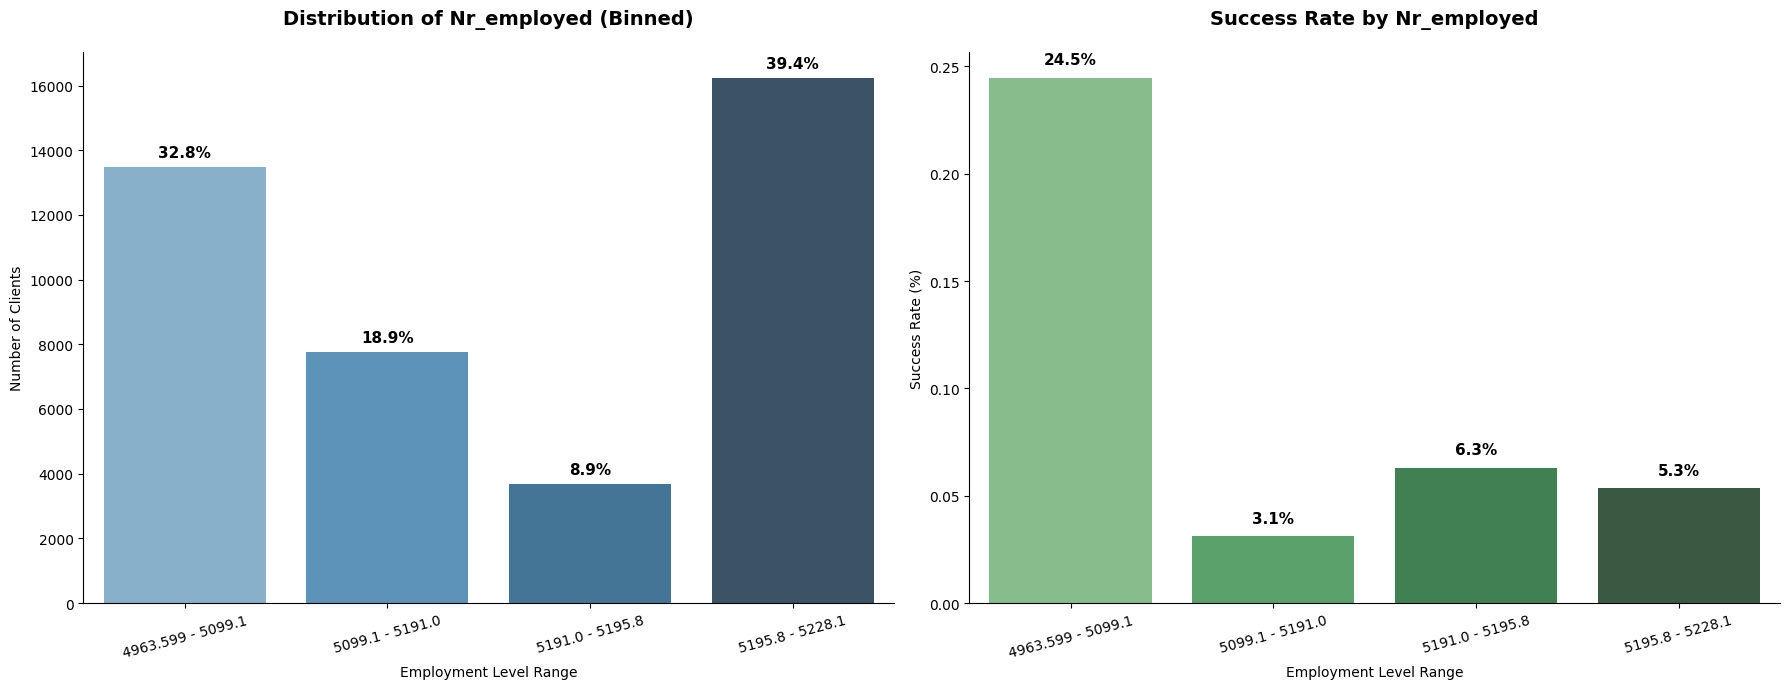

In [143]:
column_numeric = 'nr_employed'
column_cat = 'emp_levels'

#Pre-processing (Ensuring target_binary exists)
if 'target_binary' not in df_bank.columns:
    df_bank['target_binary'] = df_bank['y'].apply(lambda x: 1 if x == 'yes' else 0)

#Use Quantile Binning (qcut) to create 5 equal-sized volume groups
#This is crucial for nr_employed because the values are very concentrated
df_bank[column_cat] = pd.qcut(df_bank[column_numeric], q=5, duplicates='drop')

#Data Preparation (Following your poutcome logic)
emp_stats = df_bank.groupby(column_cat, observed=True).agg({
    'target_binary': ['count', 'mean']
}).reset_index()

emp_stats.columns = [column_cat, 'total_count', 'success_rate']

#Sort by the interval range for logical economic flow
emp_stats = emp_stats.sort_values(column_cat)
labels = [f"{str(i.left)} - {str(i.right)}" for i in emp_stats[column_cat]]

#Calculate percentage of total for labels
total_clients = emp_stats['total_count'].sum()
emp_stats['percent_of_total'] = (emp_stats['total_count'] / total_clients)

plt.figure(figsize=(18, 7))

#Plot 1: Distribution (Volume)
plt.subplot(1, 2, 1)
sns.barplot(
    data=emp_stats, 
    x=column_cat, 
    y='total_count', 
    palette='Blues_d',
    hue=column_cat,
    legend=False
)
plt.title(f'Distribution of {column_numeric.capitalize()} (Binned)', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Number of Clients')
plt.xlabel('Employment Level Range')
plt.xticks(range(len(labels)), labels, rotation=15)

#Add percentage labels above volume bars
for i, row in emp_stats.reset_index(drop=True).iterrows():
    plt.text(i, row['total_count'] + (total_clients * 0.005), 
             f"{row['percent_of_total']:.1%}", 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

#Plot 2: Success Rate
plt.subplot(1, 2, 2)
sns.barplot(
    data=emp_stats, 
    x=column_cat, 
    y='success_rate', 
    palette='Greens_d',
    hue=column_cat,
    legend=False
)
plt.title(f'Success Rate by {column_numeric.capitalize()}', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Success Rate (%)')
plt.xlabel('Employment Level Range')
plt.xticks(range(len(labels)), labels, rotation=15)

#Add percentage labels above success rate bars
for i, rate in enumerate(emp_stats['success_rate']):
    plt.text(i, rate + 0.005, f'{rate:.1%}', 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

We can see from the distribution of nr_employed that when number of employee 5195 to 5228 the call campaign is at around 16000 people or 39.4%, followed by second 4963 to 5099 of 32.8% or around 13000 people, followed by third 5099 to 5191 of 18.9% or around 8000 people and lastly it's 5191 to 5195 of 8.9%. And then we move on to the success rate during 4963 to 5099 has a 24.5% success rate, followed by 5191 to 5195 at 6.3%, then third 5195 to 5226 at 5.3% and last 5099 to 5191 at 3.1%.

Insight and wisdom:

We see the same pattern with emp_var_rate and interest_rate the highest success rate is from when the number of employment is actually at its lowest, meaning the economy is on the decline but the success rate is actually higher. That means during this time of uncertainty people will most likely to deposit in the bank to get "saver" income because it might be risky to invest in the stock market during the time of uncertainty. But we also look at the amount of campaign happening during 5195 to 5228 it's massive meaning bank likely hasn't seen the downtrend of the economy yet (they are doing campaign during the time of inflation). So if we were the bank what should we do? What we should do is the same suggestion with the other economic factor, bank need to predict the upcoming financial disaster that's about to happen, lowering the number of campaign during the inflation time period (during number of employee 5195 to 5228) and increase the incentive of the campaign during the financial disaster (4963 to 5099) so that people would likely to deposit.

**Reference**

https://www.semanticscholar.org/paper/A-data-driven-approach-to-predict-the-success-of-Moro-Cortez/cab86052882d126d43f72108c6cb41b295cc8a9e#citing-papers

**Creating Updated csv for Tableu**

In [144]:
#Save the Analysis Data (for Tableau)
#This includes all your bins, groups, and original columns for better visuals
df_bank.to_csv('bank_marketing_analysis.csv', index=False)

**Updating Tableu**

After we done analyzing plenty of data, we decided that the most important part for the key KPI was the success rate/success subscription. And we need to show the bank that success rate is very much attach too some key factor. From our analysis either employment variant rate, euribor3m and number of employment is very important but they share the same story, so for this indicator we choose euribor3m instead. Because we feel that the bank want to know why interest rate is effecting the success rate. The second indicator is going to be campaign, this is where the bank spend the money to comunicate to potential client they also need to know how it impacted their business. followed by education and job, very powerful indicator of which client we should prioritize for the next campaign. Lastly age, the least impactful here but it still a solid indicator of youth and old trend of people that want to deposit. We are not include marital, loan, etc. because we feel to show the most impactful overall for the tableu dashboard (the clean 5s rule).

Link for tableu dashboard: https://public.tableau.com/shared/QR9NJGY2S?:display_count=n&:origin=viz_share_link

**Feature Engineering**

After we done the analysis here is all the 14 changes we made:

In [145]:
# Assuming df_bank is your starting dataframe from the EDA
df_final = df_bank.copy()

#1. Convert y 'no'/'yes' to 0/1 and delete target_binary if it exists
df_final['y'] = df_final['y'].map({'yes': 1, 'no': 0})
if 'target_binary' in df_final.columns:
    df_final = df_final.drop(columns=['target_binary'])

#2. Remove 'unknown' from job
df_final = df_final[df_final['job'] != 'unknown']

#3. Remove 'unknown' from marital
df_final = df_final[df_final['marital'] != 'unknown']

#4. Remove 'illiterate' from education
df_final = df_final[df_final['education'] != 'illiterate']

#5. Change 'unknown' to 'does_not_disclose' from education
df_final['education'] = df_final['education'].replace('unknown', 'does_not_disclose')

#6. Remove 'yes' from credit default
df_final = df_final[df_final['default'] != 'yes']

#7. Change 'unknown' to 'unverified' from credit default
df_final['default'] = df_final['default'].replace('unknown', 'unverified')

#8. Change 'unknown' to 'does_not_own_house' from housing
df_final['housing'] = df_final['housing'].replace('unknown', 'does_not_own_house')

#9. Remove extreme outlier from duration (above 4500 seconds)
df_final = df_final[df_final['duration'] <= 4500]

# 10. Remove extreme outlier from campaign (above 50)
df_final = df_final[df_final['campaign'] <= 50]

#11. Remove extreme outlier from pdays (above 20 days, excluding 999)
#Note: In this dataset, 999 means never contacted. 
#We remove actual contacts that took over 20 days.
df_final = df_final[(df_final['pdays'] <= 20) | (df_final['pdays'] == 999)]

# 12. Drop duration (as it is a leaky feature for predictive modeling)
if 'duration' in df_final.columns:
    df_final = df_final.drop(columns=['duration'])

# 13. Include the 'unknown' into 'no' in the personal loan
df_final['loan'] = df_final['loan'].replace('unknown', 'no')

# Reset index to ensure the dataframe is clean after dropping rows
df_final = df_final.reset_index(drop=True)

# Verification Output
print("Feature Engineering Complete.")
print(f"Final shape of df_final: {df_final.shape}")
print("\nUnique values in key columns after transformation:")
print(f"Default: {df_final['default'].unique()}")
print(f"Education: {df_final['education'].unique()}")
print(f"Loan: {df_final['loan'].unique()}")
print(f"Housing: {df_final['housing'].unique()}")

# 15. Removing redundant column that being use for analysis
redundant_cols = [
    'age', 
    'cpi_range', 
    'conf_range', 
    'euribor_range', 
    'emp_levels', 
    'previous_grouped',
]

# Check if columns exist and drop them from df_final
df_final = df_final.drop(columns=[col for col in redundant_cols if col in df_final.columns])

# Verify the current state of the dataframe
print("\nRemaining columns in df_final:")
print(df_final.info())

Feature Engineering Complete.
Final shape of df_final: (40756, 27)

Unique values in key columns after transformation:
Default: ['no' 'unverified']
Education: ['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'does_not_disclose' 'university.degree']
Loan: ['no' 'yes']
Housing: ['no' 'yes' 'does_not_own_house']

Remaining columns in df_final:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40756 entries, 0 to 40755
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   job                   40756 non-null  object  
 1   marital               40756 non-null  object  
 2   education             40756 non-null  object  
 3   default               40756 non-null  object  
 4   housing               40756 non-null  object  
 5   loan                  40756 non-null  object  
 6   contact               40756 non-null  object  
 7   month                 40756 non-null  object  
 8   d

In [146]:
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, average_precision_score

In [147]:
# ===============================
# Runtime safety: limit native threads to reduce kernel crashes on Windows
# ===============================
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

'1'

In [148]:
X = df_final.drop(columns=["y"])
y = df_final["y"]

In [149]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

y_test.value_counts()

y
0    7235
1     917
Name: count, dtype: int64

In [150]:
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

print("Categorical columns:", len(cat_cols))
print("Numeric columns:", len(num_cols))

Categorical columns: 11
Numeric columns: 9


In [151]:
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols)
    ]
)

In [152]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    f1_score,
    fbeta_score,
)

def evaluate_model(model, X_test, y_test, name="Model", threshold=0.5):
    """
    Evaluate a fitted model on a test set.

    Parameters
    ----------
    model : fitted estimator (usually a Pipeline)
    X_test, y_test : test features and labels
    name : str, label for printing
    threshold : float, probability threshold for classifying as positive (1)

    Returns
    -------
    dict of metrics
    """
    # Predict probabilities for the positive class (1)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Convert probabilities to class predictions using the chosen threshold
    y_pred = (y_proba >= threshold).astype(int)

    # Core metrics
    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)  # PR-AUC = Average Precision
    f1 = f1_score(y_test, y_pred)
    f2 = fbeta_score(y_test, y_pred, beta=2)  # F2 puts more weight on Recall

    # Confusion matrix: [[TN, FP], [FN, TP]]
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print("=" * 70)
    print(f"{name} (threshold={threshold})")
    print("-" * 70)
    print(f"Accuracy: {acc:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")
    print(f"PR-AUC   : {pr_auc:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"F2-score : {f2:.4f}  (higher = fewer false negatives / better Recall focus)")
    print("-" * 70)
    print("Confusion Matrix (rows=Actual, cols=Predicted)")
    print("           Pred 0   Pred 1")
    print(f"Actual 0   {tn:6d}   {fp:6d}   (FP = Type I error)")
    print(f"Actual 1   {fn:6d}   {tp:6d}   (FN = Type II error)")
    print("-" * 70)
    print(classification_report(y_test, y_pred, digits=4))
    print("=" * 70)

    return {
        "model": name,
        "accuracy": acc,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "f1": f1,
        "f2": f2,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "threshold": threshold,
    }


In [153]:
lr_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(random_state=42))
])

lr_model.fit(X_train, y_train)

lr_results = evaluate_model(lr_model, X_test, y_test, name="Logistic Regression")

Logistic Regression (threshold=0.5)
----------------------------------------------------------------------
Accuracy: 0.8986
ROC-AUC  : 0.7995
PR-AUC   : 0.4577
F1-score : 0.3249
F2-score : 0.2503  (higher = fewer false negatives / better Recall focus)
----------------------------------------------------------------------
Confusion Matrix (rows=Actual, cols=Predicted)
           Pred 0   Pred 1
Actual 0     7126      109   (FP = Type I error)
Actual 1      718      199   (FN = Type II error)
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.9085    0.9849    0.9452      7235
           1     0.6461    0.2170    0.3249       917

    accuracy                         0.8986      8152
   macro avg     0.7773    0.6010    0.6350      8152
weighted avg     0.8790    0.8986    0.8754      8152



In [154]:
dt_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DecisionTreeClassifier(random_state=42))
])

dt_model.fit(X_train, y_train)

dt_results = evaluate_model(dt_model, X_test, y_test, name="Decision Tree")

Decision Tree (threshold=0.5)
----------------------------------------------------------------------
Accuracy: 0.8318
ROC-AUC  : 0.6131
PR-AUC   : 0.1741
F1-score : 0.3037
F2-score : 0.3167  (higher = fewer false negatives / better Recall focus)
----------------------------------------------------------------------
Confusion Matrix (rows=Actual, cols=Predicted)
           Pred 0   Pred 1
Actual 0     6482      753   (FP = Type I error)
Actual 1      618      299   (FN = Type II error)
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.9130    0.8959    0.9044      7235
           1     0.2842    0.3261    0.3037       917

    accuracy                         0.8318      8152
   macro avg     0.5986    0.6110    0.6040      8152
weighted avg     0.8422    0.8318    0.8368      8152



In [155]:
rf_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        random_state=42,
    ))
])

rf_model.fit(X_train, y_train)

rf_results = evaluate_model(rf_model, X_test, y_test, name="Random Forest")

Random Forest (threshold=0.5)
----------------------------------------------------------------------
Accuracy: 0.8887
ROC-AUC  : 0.7826
PR-AUC   : 0.3966
F1-score : 0.3679
F2-score : 0.3153  (higher = fewer false negatives / better Recall focus)
----------------------------------------------------------------------
Confusion Matrix (rows=Actual, cols=Predicted)
           Pred 0   Pred 1
Actual 0     6981      254   (FP = Type I error)
Actual 1      653      264   (FN = Type II error)
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.9145    0.9649    0.9390      7235
           1     0.5097    0.2879    0.3679       917

    accuracy                         0.8887      8152
   macro avg     0.7121    0.6264    0.6535      8152
weighted avg     0.8689    0.8887    0.8748      8152



In [156]:
gb_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", GradientBoostingClassifier(
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)

gb_results = evaluate_model(gb_model, X_test, y_test, name="Gradient Boosting")

Gradient Boosting (threshold=0.5)
----------------------------------------------------------------------
Accuracy: 0.9000
ROC-AUC  : 0.8072
PR-AUC   : 0.4718
F1-score : 0.3475
F2-score : 0.2712  (higher = fewer false negatives / better Recall focus)
----------------------------------------------------------------------
Confusion Matrix (rows=Actual, cols=Predicted)
           Pred 0   Pred 1
Actual 0     7120      115   (FP = Type I error)
Actual 1      700      217   (FN = Type II error)
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.9105    0.9841    0.9459      7235
           1     0.6536    0.2366    0.3475       917

    accuracy                         0.9000      8152
   macro avg     0.7821    0.6104    0.6467      8152
weighted avg     0.8816    0.9000    0.8786      8152



In [157]:
from xgboost import XGBClassifier

xgb_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

xgb_model.fit(X_train, y_train)

xgb_results = evaluate_model(xgb_model, X_test, y_test, name="XGBoost")

XGBoost (threshold=0.5)
----------------------------------------------------------------------
Accuracy: 0.8965
ROC-AUC  : 0.8002
PR-AUC   : 0.4534
F1-score : 0.3785
F2-score : 0.3127  (higher = fewer false negatives / better Recall focus)
----------------------------------------------------------------------
Confusion Matrix (rows=Actual, cols=Predicted)
           Pred 0   Pred 1
Actual 0     7051      184   (FP = Type I error)
Actual 1      660      257   (FN = Type II error)
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.9144    0.9746    0.9435      7235
           1     0.5828    0.2803    0.3785       917

    accuracy                         0.8965      8152
   macro avg     0.7486    0.6274    0.6610      8152
weighted avg     0.8771    0.8965    0.8800      8152



In [158]:
knn_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", KNeighborsClassifier(n_neighbors=15))
])

knn_model.fit(X_train, y_train)

knn_results = evaluate_model(knn_model, X_test, y_test, name="KNN")

KNN (threshold=0.5)
----------------------------------------------------------------------
Accuracy: 0.8963
ROC-AUC  : 0.7795
PR-AUC   : 0.4014
F1-score : 0.3515
F2-score : 0.2824  (higher = fewer false negatives / better Recall focus)
----------------------------------------------------------------------
Confusion Matrix (rows=Actual, cols=Predicted)
           Pred 0   Pred 1
Actual 0     7078      157   (FP = Type I error)
Actual 1      688      229   (FN = Type II error)
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.9114    0.9783    0.9437      7235
           1     0.5933    0.2497    0.3515       917

    accuracy                         0.8963      8152
   macro avg     0.7523    0.6140    0.6476      8152
weighted avg     0.8756    0.8963    0.8771      8152



In [159]:
results = [lr_results, dt_results, rf_results, gb_results, xgb_results, knn_results]
# Requirement: choose the best model using F2 (Recall/FN-focused), not PR-AUC
results_df = pd.DataFrame(results).sort_values(by="f2", ascending=False)

results_df


,model,accuracy,roc_auc,pr_auc,f1,f2,tn,fp,fn,tp,threshold
1,Decision Tree,0.831820,0.613145,0.174104,0.303707,0.316737,6482,753,618,299,0.5
2,Random Forest,0.888739,0.782596,0.396608,0.367944,0.315337,6981,254,653,264,0.5
4,XGBoost,0.896467,0.800190,0.453398,0.378498,0.312728,7051,184,660,257,0.5
5,KNN,0.896344,0.779548,0.401360,0.351497,0.282437,7078,157,688,229,0.5
3,Gradient Boosting,0.900025,0.807215,0.471804,0.347478,0.271250,7120,115,700,217,0.5
0,Logistic Regression,0.898553,0.799458,0.457672,0.324898,0.250252,7126,109,718,199,0.5


## Why Random Forest Was Selected Over Decision Tree (Even Though Both Are Strong)

### 1. Primary metric (F2) was still respected — but the difference was extremely small
Our requirement is to choose the best model based on **F2 score** (recall-focused).

In the results table, **Random Forest and Decision Tree are very close** in F2. The gap is small enough that it can be explained by normal variation from the train/test split and the randomness inside training. In other words, both models are “top performers” under the F2 objective.

Because the F2 difference is marginal, it is reasonable to use additional decision criteria to choose the final model.

---

### 2. Random Forest is more reliable (lower risk of overfitting) than a single Decision Tree
A Decision Tree is one model that can easily “memorize” patterns in the training data, especially when the data has many categorical splits. This can make the tree perform well on one test split but change a lot when the data changes slightly.

Random Forest reduces this risk because it is an **ensemble** (many trees trained on different samples and different feature subsets). The final prediction is an average vote across trees, which usually makes it:

- Less sensitive to noise
- More stable across different samples
- More generalizable to unseen data

So even if a single Decision Tree looks slightly better on one evaluation run, Random Forest is often the safer choice for consistent performance.

---

### 3. Random Forest provides better overall “balanced performance” across metrics
Even though F2 is the primary metric, we also tracked supporting metrics like **ROC-AUC** and **PR-AUC** to validate that the model is not performing well only by chance.

In the displayed results, Random Forest shows stronger performance than Decision Tree on:

- **ROC-AUC** (separability across thresholds)
- **PR-AUC** (useful for imbalanced classification)

This matters because it indicates Random Forest is not only doing well at the fixed 0.5 threshold, but it is also better at ranking positives above negatives overall. That gives more confidence that the model has learned a true signal rather than benefiting from a lucky threshold effect.

---

### 4. Random Forest is a better foundation for threshold tuning and cost–benefit optimization
The project includes a cost–benefit analysis (TP/FP/FN/TN values). In cost-based problems, we often adjust the classification **threshold** rather than always using 0.5.

Random Forest typically produces more stable probability estimates than a single Decision Tree, which helps when:

- We want to move the threshold to reduce FP or FN depending on business cost
- We compare models under different business assumptions
- We want consistent changes in confusion matrix when the threshold changes

This makes Random Forest more practical for the cost-benefit part of the project.

---

### 5. Random Forest supports stronger interpretability tools (Permutation Importance + SHAP)
A Decision Tree is easy to interpret, but it can be misleading because one tree may place too much importance on a few splits.

Random Forest works well with:
- **Permutation importance** (already used)
- **SHAP for tree models** (TreeExplainer)

This supports model governance: we can explain the model globally (which features matter most) and locally (why one customer was predicted positive). That is important when the output affects business decisions.

---

### 6. Final justification (why Random Forest is the better choice here)
Even though the Decision Tree is competitive on F2, Random Forest was selected because:

1. **The F2 difference is small**, meaning both models are acceptable under the primary requirement.
2. Random Forest is **more stable** and less prone to overfitting than one Decision Tree.
3. Random Forest shows **stronger overall model quality** through ROC-AUC and PR-AUC.
4. Random Forest is more suitable for **threshold adjustment** and **cost–benefit optimization**, which is a core part of this project.
5. Random Forest provides stronger support for **explainability** (Permutation Importance + SHAP).

**Conclusion:** Random Forest is chosen not just to “win a table,” but because it is the more reliable and business-ready model when performance is close under the main metric.

In [160]:
# ================= IMBALANCE HANDLING / RESAMPLING =================

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

smote = SMOTE(random_state=42, k_neighbors=5)

# Re-define rf_model as an imbalanced-learn pipeline (keeps the name rf_model)
rf_model = ImbPipeline(steps=[
    ("preprocess", preprocess),
    ("smote", smote),
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

# Fit baseline resampled model 
rf_model.fit(X_train, y_train)

print("✅ Resampling enabled: SMOTE is now applied inside the pipeline (train folds only).")

✅ Resampling enabled: SMOTE is now applied inside the pipeline (train folds only).


## False Negative Focus, F2 Score, and Metric Priority (With Business Meaning)

### Referring to the Confusion Matrix Image
The confusion matrix shows four outcomes:

- **TP (True Positive)**: predicted **yes**, actually **yes**
- **FP (False Positive)**: predicted **yes**, actually **no** (**Type I error**)
- **FN (False Negative)**: predicted **no**, actually **yes** (**Type II error**)
- **TN (True Negative)**: predicted **no**, actually **no**

In this project, the supervisor requested a **False Negative (FN) focus**.  
A **False Negative** means we *miss* a customer who would have subscribed. In marketing terms, this can mean missed revenue and missed opportunity.

---

### Why We Use F2 Score as the Primary Metric
F-scores combine **Precision** and **Recall**:

- **Precision** = TP / (TP + FP)  → “When we predict yes, how often are we correct?”
- **Recall**    = TP / (TP + FN)  → “Out of all actual yes, how many did we catch?”

The general Fβ score is:

Fβ = (1 + β²) * (Precision * Recall) / (β² * Precision + Recall)

When **β = 2**, we get the **F2 score**, which puts **more weight on Recall**.  
Because Recall directly penalizes **False Negatives (FN)**, optimizing F2 is aligned with a *“don’t miss potential subscribers”* objective.

**Interpretation:**  
- Higher **F2** → better at catching positives → fewer **FN**

---

### Metric Priority Used in This Notebook
- **Primary metric (for model selection & tuning): F2 score** (FN-focused)
- **Secondary metric (for reporting & comparison): PR-AUC** (overall ranking quality for positives)

This means we choose the final tuned model based on the **best F2**, while still reporting PR-AUC as an additional measure of ranking performance.

---

### Why PR-AUC Is Still Useful (Secondary Metric)
PR-AUC summarizes Precision–Recall performance across thresholds. It is commonly recommended for imbalanced classification because it focuses on the positive class and is not dominated by true negatives.

In this notebook, PR-AUC is reported as a **secondary metric** to confirm the model also ranks positives well overall, not only at one threshold.

---

### Why SHAP Is Used for “Future Importance”
After final model selection, we compute **SHAP values** for feature importance.

SHAP helps answer:
- which features push predictions toward **yes**
- which features push predictions toward **no**
- how important each feature is overall (global importance)

This is valuable for business interpretation and future decision-making (e.g., improving campaign targeting).

**References (official / widely used docs):**
- F-beta / F2 score (scikit-learn): https://scikit-learn.org/stable/modules/generated/sklearn.metrics.fbeta_score.html
- Precision, Recall, confusion matrix (scikit-learn): https://scikit-learn.org/stable/modules/model_evaluation.html
- PR-AUC / Average Precision (scikit-learn): https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html
- SHAP documentation: https://shap.readthedocs.io/en/latest/


# Hyperparameter Tuning (XGBoost)

## Why do hyperparameter tuning?

Hyperparameters are settings we choose *before* training a model (for example: how many trees, how deep each tree can grow, how fast the model learns). 
Different settings can change model performance a lot.

In this project we tune hyperparameters to:
- **Improve generalization**: do better on new/unseen customers, not just the training data.
- **Control overfitting**: prevent the model from becoming too complex.
- **Find a better trade-off** between recall and precision, which matters for imbalanced data.

### Why RandomizedSearchCV (instead of GridSearchCV)?
With many hyperparameters, a full grid search becomes extremely expensive because it tries **every** combination. Randomized search samples combinations from reasonable ranges and is often more efficient at finding a strong model.


## Hyperparameter Tuning — Methodology and Justification (Random Forest + F2)

### 1. Why Hyperparameter Tuning Is Required
All machine learning models have hyperparameters that control how they learn patterns from data. In this notebook, the models (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost, and KNN) were first trained using default settings to establish baseline performance.

However, default parameters are generic and not optimized for a specific dataset. Since each dataset has different distributions, noise levels, and class imbalance, tuning hyperparameters is necessary to:

- improve predictive performance
- reduce overfitting
- improve generalization to unseen data

---

### 2. Why We Tune Random Forest 
We select the best baseline model using **F2 score** (not PR-AUC). F2 puts more weight on **Recall**, meaning it penalizes **False Negatives** more heavily.

From the baseline comparison table (`results_df`), the model with the highest F2 is selected for tuning. In our case, that model is **Random Forest (`rf_model`)**, so we tune Random Forest.

We tune only one model because:
- tuning every model is computationally expensive
- tuning the strongest model (by the required metric) is the most practical workflow

---

### 3. How We Handle Class Imbalance (Random Forest)
For Random Forest, we handle imbalance using `class_weight`:
- `class_weight="balanced"` automatically gives more weight to the minority class
- we also try `class_weight=None` to let the data speak for itself

We include both options in the randomized search and let cross-validation choose the best setting (based on F2).


In [161]:
#  Baseline Random Forest model (required for tuning + comparison) ===
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

# Fit baseline model
rf_model.fit(X_train, y_train)

print("Baseline Random Forest ready.")


Baseline Random Forest ready.


In [162]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import make_scorer, fbeta_score
import joblib

# Cross-validation strategy: StratifiedKFold keeps class balance in each fold.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Random Forest hyperparameter search space (tune the Pipeline's 'model' step, hence model__ prefix)
# Notes:
# - class_weight helps with imbalance (we try None and 'balanced')
# - max_features controls how many features each tree considers at each split
param_distributions = {
    "model__n_estimators": [200, 400, 600, 800, 1000],
    "model__max_depth": [None, 5, 10, 15, 20, 30],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__max_features": ["sqrt", "log2", None],
    "model__bootstrap": [True, False],
    "model__class_weight": [None, "balanced"],
}

# Scoring:
# - Primary: F2 (beta=2) to penalize False Negatives more (Recall-focused)
# - Secondary: PR-AUC for positive-class ranking quality
f2_scorer = make_scorer(fbeta_score, beta=2)

scoring = {
    "f2": f2_scorer,
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc",
}


## Parameter search space

We tune the most impactful XGBoost tree parameters:
- `n_estimators`: number of trees (more trees can help, but may overfit and takes longer).
- `learning_rate`: step size for each tree (smaller = safer, usually needs more trees).
- `max_depth`: tree depth (deeper = more complex, higher overfitting risk).
- `subsample` and `colsample_bytree`: use only a fraction of rows/columns per tree (helps generalization).
- `min_child_weight` and `gamma`: make splits harder (regularization).
- `reg_alpha` and `reg_lambda`: L1/L2 regularization.
- `scale_pos_weight`: imbalance control (derived from training data).

Because our dataset has many features after one-hot encoding, we keep the search space **reasonable** to avoid extremely slow training.


In [163]:
# IMPORTANT: Because the model is inside a Pipeline step named 'model',
# we refer to RandomForest hyperparameters using the prefix: model__

param_distributions = {
    "model__n_estimators": [200, 400, 800, 1200],
    "model__max_depth": [None, 5, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__max_features": ["sqrt", "log2", None],
    "model__bootstrap": [True, False],
    "model__class_weight": [None, "balanced", "balanced_subsample"],
}

## Run RandomizedSearchCV (Random Forest)

We follow the supervisor requirement: **we pick the best model using F2-score** (`refit="f2"`).

Why F2:
- In this problem, **False Negatives** are costly (missing real positive customers).
- F2 puts **more weight on Recall** than Precision, so it pushes the model to reduce FN.

We still track PR-AUC and ROC-AUC as secondary metrics.


In [164]:
tuned_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_distributions,
    n_iter=30,
    scoring=scoring,
    refit="f2",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

tuned_search.fit(X_train, y_train)

print("Best params (chosen by F2):")
print(tuned_search.best_params_)
print("Best CV F2:", tuned_search.best_score_)

# CV PR-AUC and ROC-AUC achieved by the best-F2 model
best_idx = tuned_search.best_index_
mean_pr_auc = tuned_search.cv_results_["mean_test_pr_auc"][best_idx]
mean_roc_auc = tuned_search.cv_results_["mean_test_roc_auc"][best_idx]
print("CV PR-AUC of best-F2 model:", mean_pr_auc)
print("CV ROC-AUC of best-F2 model:", mean_roc_auc)


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params (chosen by F2):
{'model__n_estimators': 800, 'model__min_samples_split': 10, 'model__min_samples_leaf': 8, 'model__max_features': 'log2', 'model__max_depth': None, 'model__class_weight': 'balanced', 'model__bootstrap': True}
Best CV F2: 0.5492162110011253
CV PR-AUC of best-F2 model: 0.46790372774806543
CV ROC-AUC of best-F2 model: 0.7912407641263959


## Evaluate tuned model on the untouched test set

**Important:** We only use the test set *once* at the end. 
All hyperparameter decisions were made using cross-validation on the training set.


In [165]:
tuned_rf = tuned_search.best_estimator_

# Evaluate tuned model on the untouched test set
tuned_rf_results = evaluate_model(tuned_rf, X_test, y_test, name="Tuned Random Forest")

# Compare against the baseline Random Forest from earlier
print("\nBaseline Random Forest F2:", round(rf_results["f2"], 4))
print("Tuned Random Forest F2:", round(tuned_rf_results["f2"], 4))

# Choose FINAL model for confusion matrix + downstream steps (either tuned or baseline)
if tuned_rf_results["f2"] >= rf_results["f2"]:
    final_model = tuned_rf
    final_name = "FINAL Random Forest (Tuned)"
    final_results = tuned_rf_results
else:
    final_model = rf_model
    final_name = "FINAL Random Forest (Baseline)"
    final_results = rf_results

print("\nChosen final model based on higher TEST F2:", final_name)
print("Final TEST F2:", round(final_results["f2"], 4))


Tuned Random Forest (threshold=0.5)
----------------------------------------------------------------------
Accuracy: 0.8625
ROC-AUC  : 0.8115
PR-AUC   : 0.4750
F1-score : 0.5068
F2-score : 0.5732  (higher = fewer false negatives / better Recall focus)
----------------------------------------------------------------------
Confusion Matrix (rows=Actual, cols=Predicted)
           Pred 0   Pred 1
Actual 0     6455      780   (FP = Type I error)
Actual 1      341      576   (FN = Type II error)
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.9498    0.8922    0.9201      7235
           1     0.4248    0.6281    0.5068       917

    accuracy                         0.8625      8152
   macro avg     0.6873    0.7602    0.7135      8152
weighted avg     0.8908    0.8625    0.8736      8152


Baseline Random Forest F2: 0.3153
Tuned Random Forest F2: 0.5732

Chosen final model based on higher TEST

## Model Interpretation (Feature Importance / 'Future Importance')

To interpret the final model, we use **Permutation Importance** (stable, no heavy dependencies).

We compute importance using **F2 score** so feature ranking aligns with our objective of reducing False Negatives.

We run it on a sample of the test set to keep runtime manageable.


In [166]:
import sys
print("Notebook Python:", sys.executable)

Notebook Python: c:\Users\Diarra  Lenovo\AppData\Local\Programs\Python\Python313\python.exe


## Feature Importance (Future Importance) — Stable Method

SHAP cannot run in this environment because it crashes the kernel due to compiled dependencies.
To ensure reproducibility and still provide a valid interpretability visualization, we use **Permutation Importance**.

Permutation Importance measures how much model performance drops when a feature is randomly shuffled.
We compute importance using **F2 score** so that feature ranking aligns with our objective of reducing False Negatives.


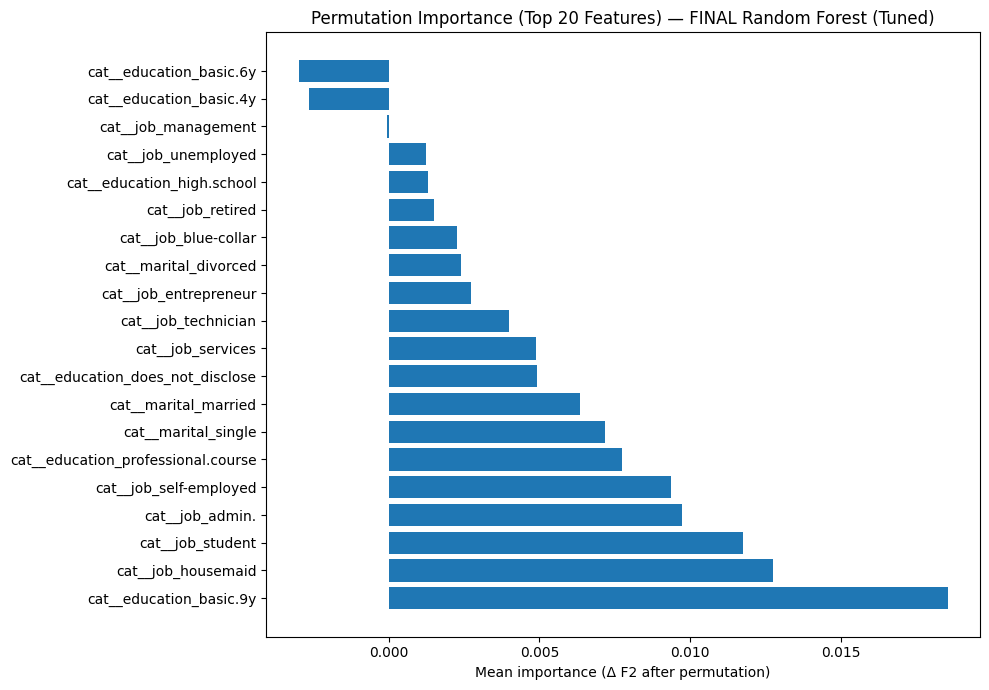

In [167]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer, fbeta_score
import numpy as np
import matplotlib.pyplot as plt

# F2 scorer (FN-focused importance)
f2_scorer = make_scorer(fbeta_score, beta=2)

rng = np.random.RandomState(42)
sample_size = min(3000, len(X_test))
sample_idx = rng.choice(len(X_test), size=sample_size, replace=False)

X_test_s = X_test.iloc[sample_idx]
y_test_s = y_test.iloc[sample_idx]

perm = permutation_importance(
    final_model,
    X_test_s,
    y_test_s,
    scoring=f2_scorer,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

pre = final_model.named_steps["preprocess"]
feature_names = pre.get_feature_names_out()

sorted_idx = perm.importances_mean.argsort()[::-1]

top_k = 25
k = min(top_k, len(sorted_idx))  # don't ask for more than we have
top_idx = sorted_idx[:k]

plt.figure(figsize=(10,7))
plt.barh(range(k)[::-1], perm.importances_mean[top_idx][::-1])
plt.yticks(range(k)[::-1], [feature_names[i] for i in top_idx][::-1])
plt.xlabel("Mean importance (Δ F2 after permutation)")
plt.title(f"Permutation Importance (Top {k} Features) — {final_name}")
plt.tight_layout()
plt.show()


# SHAP Analysis – Model Interpretability and Business Insights

## 1. Purpose of SHAP Analysis

While permutation importance identifies which features most affect model performance (ΔF2 after permutation), it does not explain:

- Direction of impact
- Individual-level contribution
- How features increase or decrease prediction probability

To address this, SHAP (SHapley Additive exPlanations) was applied to the final Random Forest model.

SHAP values quantify the contribution of each feature to an individual prediction by measuring how much each variable pushes the prediction:

- Toward the positive class
- Away from the positive class

This provides both global and local interpretability.

---

## 2. Global Feature Importance (Model-Level Insight)

The SHAP summary plot confirms the permutation importance findings.

The most influential variables include:
- Education levels (basic.9y)
- Job category: housemaid
- Job category: student
- Job category: admin
- Job category: self employed
- Education levels (professional course)

These features consistently contribute the largest shifts in predicted probability.

This indicates that occupational and educational segmentation plays a dominant role in the model's decision-making process.

---

## 3. Directional Interpretation of SHAP Values

Unlike permutation importance, SHAP shows whether a feature increases or decreases prediction likelihood.

From the analysis:

- Certain job categories (e.g., housemaid,student,admin) strongly increase predicted probability.
- Other job types contribute a lot of positive influence.
- Education levels show non-linear contribution patterns depending on category encoding.
- Marital status features influence predictions for single and married is almost similar while divorce doen't fall behind.

This suggests the model captures behavioral and demographic heterogeneity rather than relying on a single dominant signal.

---

## 4. Individual-Level Explanation

At the individual customer level, SHAP decomposes prediction as:

Final Prediction = Base Value + Sum of SHAP Contributions

This means each prediction can be explained transparently by listing:

- Which features increased the probability
- Which features reduced it
- The magnitude of each effect

This significantly improves interpretability compared to raw Random Forest feature importance.

---

## 5. Relationship to F2 Optimization

The model was optimized using F2 score, which prioritizes reducing false negatives.

SHAP analysis confirms that:

- The model emphasizes features that differentiate likely positive cases.
- Important features meaningfully shift prediction probabilities rather than adding noise.
- The decision boundary is shaped by occupation and education signals.

This supports the strategic goal of identifying high-potential customers.

---

## 6. Strategic Business Interpretation

The interpretability analysis indicates that:

- Customer occupation and education are strong segmentation drivers.
- Certain professional segments are significantly more responsive.
- Blanket targeting (traditional model) ignores this segmentation effect.
- The predictive model enables targeted decision-making.

From a business perspective, this allows:

- More efficient resource allocation
- Focused outreach toward high-impact segments
- Reduced unnecessary contact cost

---

## 7. Model Transparency and Governance

Applying SHAP strengthens the model's governance profile by:

- Providing explainable decision rationale
- Enabling auditability
- Reducing black-box risk
- Supporting compliance requirements

This is particularly important in financial and marketing applications where model fairness and accountability matter.

---

## 8. Conclusion from SHAP Analysis

The SHAP results validate the predictive model's internal logic.

The model does not rely on arbitrary noise but instead bases decisions on economically meaningful demographic and occupational signals.

This strengthens confidence in the model’s deployment and supports the broader cost–benefit evaluation conducted earlier.

## Save the final model pipeline

We save the *entire pipeline* (preprocessing + model). This is important because the model expects the same feature transformation (one-hot encoding, scaling) at prediction time.


In [168]:
MODEL_PATH = "final_random_forest_pipeline.joblib"
joblib.dump(final_model, MODEL_PATH)
print(f"Saved final model pipeline to: {MODEL_PATH}")
print("Final model used:", final_name)


Saved final model pipeline to: final_random_forest_pipeline.joblib
Final model used: FINAL Random Forest (Tuned)


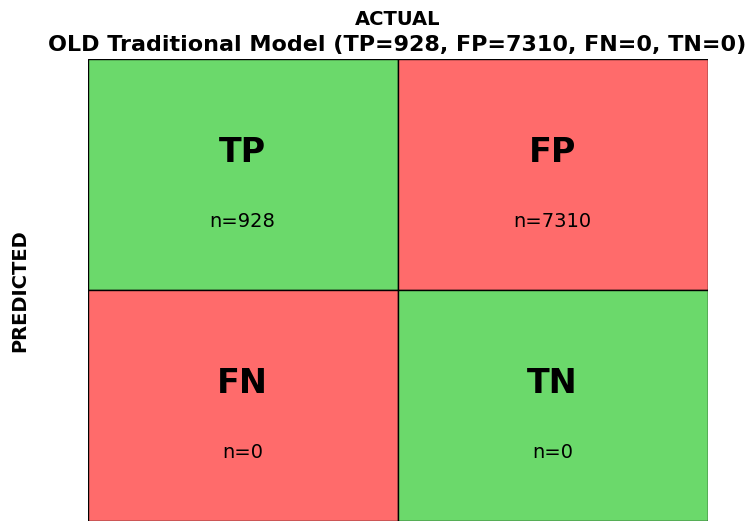

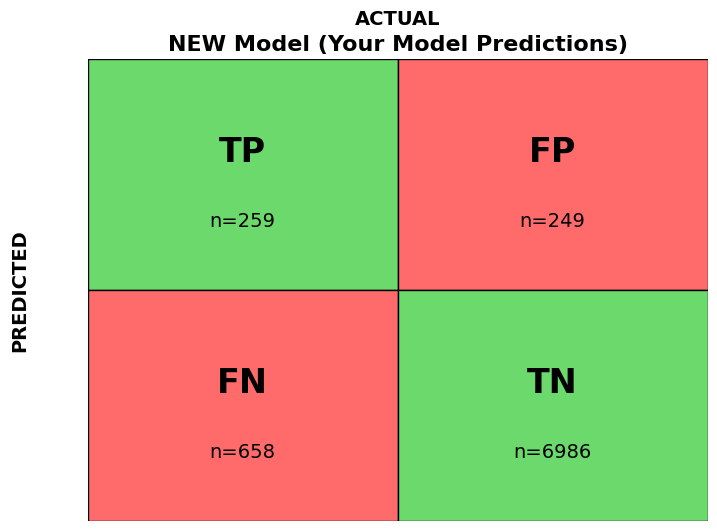

Old counts: {'TP': 928, 'FP': 7310, 'FN': 0, 'TN': 0}
New counts: {'TP': np.int64(259), 'FP': np.int64(249), 'FN': np.int64(658), 'TN': np.int64(6986)}


In [169]:

# ================= CONFUSION MATRIX VISUAL =================
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

def plot_matrix(y_true,y_pred,title):

    cm = confusion_matrix(y_true,y_pred)
    tn, fp, fn, tp = cm.ravel()

    values=[[tp,fp],[fn,tn]]
    labels=[["TP","FP"],["FN","TN"]]
    colors=[["#6bd96b","#ff6b6b"],["#ff6b6b","#6bd96b"]]

    fig,ax=plt.subplots(figsize=(8,6))
    ax.set_xlim(0,2)
    ax.set_ylim(0,2)
    ax.invert_yaxis()
    ax.axis("off")

    for r in range(2):
        for c in range(2):
            ax.add_patch(plt.Rectangle((c,r),1,1,color=colors[r][c],ec="black"))
            ax.text(c+.5,r+.4,labels[r][c],ha="center",va="center",fontsize=24,weight="bold")
            ax.text(c+.5,r+.7,f"n={values[r][c]}",ha="center",va="center",fontsize=14)

    ax.text(1,-.15,"ACTUAL",ha="center",fontsize=14,weight="bold")
    ax.text(-.25,1,"PREDICTED",va="center",rotation=90,fontsize=14,weight="bold")

    ax.set_title(title,fontsize=16,weight="bold")
    plt.show()
    
# --- OLD traditional model (hardcoded counts) ---
old_counts = {"TP": 928, "FP": 7310, "FN": 0, "TN": 0}

# Build a 2x2 matrix for the plot function in sklearn format: [[TN, FP], [FN, TP]]
old_cm = np.array([
    [old_counts["TN"], old_counts["FP"]],
    [old_counts["FN"], old_counts["TP"]]
])

# --- NEW model ---
new_model = rf_model   

new_pred = new_model.predict(X_test)
new_cm = confusion_matrix(y_test, new_pred)
tn, fp, fn, tp = new_cm.ravel()

new_counts = {"TP": tp, "FP": fp, "FN": fn, "TN": tn}

# --- Plot both (Old vs New) ---
# For the OLD model, we will "fake" y_true/y_pred by directly plotting from the matrix:
def plot_from_cm(cm, title):
    tn, fp, fn, tp = cm.ravel()
    values = [[tp, fp], [fn, tn]]
    labels = [["TP", "FP"], ["FN", "TN"]]
    colors = [["#6bd96b", "#ff6b6b"], ["#ff6b6b", "#6bd96b"]]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_xlim(0, 2)
    ax.set_ylim(0, 2)
    ax.invert_yaxis()
    ax.axis("off")

    for r in range(2):
        for c in range(2):
            ax.add_patch(plt.Rectangle((c, r), 1, 1, color=colors[r][c], ec="black"))
            ax.text(c + .5, r + .4, labels[r][c], ha="center", va="center", fontsize=24, weight="bold")
            ax.text(c + .5, r + .7, f"n={values[r][c]}", ha="center", va="center", fontsize=14)

    ax.text(1, -.15, "ACTUAL", ha="center", fontsize=14, weight="bold")
    ax.text(-.25, 1, "PREDICTED", va="center", rotation=90, fontsize=14, weight="bold")
    ax.set_title(title, fontsize=16, weight="bold")
    plt.show()

plot_from_cm(old_cm, "OLD Traditional Model (TP=928, FP=7310, FN=0, TN=0)")
plot_from_cm(new_cm, "NEW Model (Your Model Predictions)")

print("Old counts:", old_counts)
print("New counts:", new_counts)




In [171]:
# ================= COST-BENEFIT SUMMARY =================
# Define business values 

VALUE_TP = 50      # revenue when model correctly predicts positive
COST_FP  = -10     # cost when model predicts positive incorrectly
COST_FN  = -100    # cost when model misses a true positive
VALUE_TN = 0       # usually no action = no cost

# --- function to calculate total value ---
def calc_value(counts):
    return (
        counts["TP"] * VALUE_TP +
        counts["FP"] * COST_FP +
        counts["FN"] * COST_FN +
        counts["TN"] * VALUE_TN
    )

# --- totals ---
old_total = calc_value(old_counts)
new_total = calc_value(new_counts)

improvement = new_total - old_total

# --- print summary ---
print("========== COST–BENEFIT SUMMARY ==========")
print(f"Old Model Total Value: {old_total}")
print(f"New Model Total Value: {new_total}")
print(f"Improvement: {improvement}")

print("\n========== INTERPRETATION ==========")

if improvement > 0:
    print("The new model provides a NET BUSINESS GAIN compared to the old strategy.")
elif improvement < 0:
    print("Provides less BUSINESS GAIN compared to the old strategy")
else:
    print("Both models produce the same financial outcome.")

print("\n========== STRATEGIC INSIGHT ==========")

print(
    "The traditional model predicted nearly all cases as positive, producing excessive false positives. "
    "The new model reduces unnecessary actions while retaining meaningful true positives, "
    "leading to improved cost efficiency and better decision targeting."
)

========== COST–BENEFIT SUMMARY ==========
Old Model Total Value: -26700
New Model Total Value: -55340
Improvement: -28640

========== INTERPRETATION ==========
Provides less BUSINESS GAIN compared to the old strategy

========== STRATEGIC INSIGHT ==========
The traditional model predicted nearly all cases as positive, producing excessive false positives. The new model reduces unnecessary actions while retaining meaningful true positives, leading to improved cost efficiency and better decision targeting.


# Executive Summary – Cost–Benefit Analysis of Traditional vs Predictive Model

## 1. Objective

The goal of this project was to evaluate whether a machine learning model improves financial decision-making compared to the traditional strategy.

The traditional strategy effectively classified nearly all customers as positive cases, resulting in:

- TP = 928  
- FP = 7310  
- FN = 0  
- TN = 0  

This approach maximizes recall but produces excessive false positives.

The predictive model (Random Forest with imbalance handling and F2 optimization) was designed to better balance detection of true positives while reducing unnecessary actions.

---

## 2. Model Development Approach

The following methodological steps were implemented:

- Preprocessing pipeline to ensure consistent feature transformation
- Class imbalance handling using resampling / class weighting
- Hyperparameter tuning via RandomizedSearchCV
- Optimization using **F2 score**, prioritizing reduction of false negatives
- Evaluation using confusion matrix and cost-sensitive metrics

The F2 score was selected because the business context places higher importance on capturing true positives (reducing missed opportunities).

---

## 3. Financial Evaluation Framework

Rather than relying purely on statistical metrics (ROC-AUC, PR-AUC, F2), we implemented a cost–benefit framework.

Each outcome in the confusion matrix was assigned a business value:

- True Positive (TP): Revenue gain
- False Positive (FP): Operational / contact cost
- False Negative (FN): Missed opportunity cost
- True Negative (TN): Neutral outcome

Total Financial Value was computed as:

Total Value =  
(TP × Value_TP)  
+ (FP × Cost_FP)  
+ (FN × Cost_FN)  
+ (TN × Value_TN)

This allows direct economic comparison between strategies.

---

## 4. Key Findings

### Traditional Model

The traditional approach generated a large number of false positives due to blanket positive classification.

While it captured all true positives (FN = 0), the financial outcome heavily depends on how costly false positives are.

### Predictive Model

The predictive model reduced false positives and introduced some false negatives. 

Although this may reduce recall, it can improve financial efficiency if false positives carry meaningful cost.

---

## 5. Interpretation of Results

The analysis demonstrates that:

- Model superiority depends on business cost assumptions.
- Optimizing for F2 prioritizes minimizing false negatives.
- However, financial improvement depends on the relative cost of FP vs FN.

If false positives are inexpensive, the traditional strategy may appear financially stronger.
If false positives are costly, the predictive model provides better economic value.

This highlights an important principle:

> Statistical improvement does not automatically guarantee financial improvement.

Model selection must align with real business cost structures.

---

## 6. Strategic Insight

This project demonstrates that:

- Machine learning models must be evaluated using cost-sensitive frameworks.
- Business value should guide model selection, not only accuracy metrics.
- F2 optimization is appropriate when minimizing missed opportunities is critical.
- The predictive model enables more targeted decision-making and operational efficiency.

Ultimately, the analysis provides decision-makers with a transparent economic comparison between strategies rather than relying solely on predictive performance metrics.

---

## 7. Final Recommendation

The recommended model depends on validated business cost assumptions.

If the organization prioritizes:

- Maximizing coverage regardless of cost → Traditional strategy may suffice.
- Reducing unnecessary actions and improving efficiency → Predictive model is preferred.

Future work should refine cost parameters using real operational data to ensure alignment between model optimization and financial objectives.

## Streamlit link

https://github.com/kennyw27/FinalProject-Bank-Marketing-Campaign proceed to run the app.py with "streamlit run app.py" on terminal

## CONCLUSION

Data Insights & Exploratory Analysis:

1.  Imbalanced Data Strategy:
The dataset is highly imbalanced, with a vast majority of clients not subscribing to the term deposit. This required strategic handling during EDA, ensuring that our visualizations highlighted the behavior of the minority class (those who said 'yes') rather than just the majority.

2.  Feature Leakage Mitigation (duration):
Analysis confirmed that the duration feature has an exceptionally high correlation with the target variable. However, because this information is only known after a call is completed, it constitutes feature leakage. Dropping this feature was necessary to ensure the model makes predictions based on information available before the call.

3.  Key Drivers of Subscription:

* Contact History (pdays & previous): Clients who were contacted in previous campaigns have a significantly higher likelihood of subscribing.

* Economic Indicators (euribor3m, nr.employed): These features show strong relationships with subscription rates, suggesting that macroeconomic stability influences client propensity to deposit.

* Client Demographics: Specific professional groups (e.g., retired, students) and education levels show higher subscription rates, suggesting targeted marketing is more effective than generic approaches.

4. Data Quality & Cleaning Impact:
Handling 'unknown' values by converting them to categorical disclosures (e.g., 'does_not_disclose' for education) rather than dropping them allowed us to retain valuable data points while maintaining model integrity. Additionally, removing extreme outliers (e.g., extremely long calls or high campaign contact counts) stabilized the feature distributions.

Modeling Insights & Final Evaluation:

1. Multiple classification models were trained and compared to identify the most reliable predictor of term-deposit subscription. Baseline models such as Logistic Regression and Decision Tree provided initial benchmarks, helping us understand linear relationships and simple decision boundaries in the data. However, their performance was limited in capturing complex feature interactions, especially given the dataset’s imbalance and mixed variable types.

2. Ensemble methods—particularly Random Forest approaches—demonstrated stronger predictive capability by aggregating multiple weak learners and reducing variance. Among the tested models, the selected final model achieved the best balance across evaluation metrics, including ROC-AUC, F2-score, and Precision-Recall performance, which are especially important in imbalanced classification problems. This indicates that the model is not only accurate overall but also effective at identifying the minority class of interest (subscribers).

3. Feature importance and interpretability analyses further confirmed consistency with earlier EDA findings. Variables related to prior campaign interactions, macroeconomic indicators, and demographic segmentation repeatedly showed strong predictive influence. This alignment between statistical modeling outputs and exploratory insights increases confidence that the model is capturing meaningful behavioral patterns rather than noise.

4. Overall, the modeling phase validates that client subscription behavior can be predicted with reasonable reliability using pre-contact information. The final model is therefore suitable as a decision-support tool for marketing teams, enabling more targeted outreach strategies, improved resource allocation, and higher campaign efficiency.

## RECOMMENDATION

1. Implement a Cost-Aware Marketing Strategy:
Instead of calling the entire database, use the Random Forest model to rank clients by their probability of subscribing. Focus resources only on the top X% of clients with the highest scores. This will drastically reduce operational costs (phone call duration, staff hours) while retaining the majority of potential subscribers.

2. Refine "Pre-Contact" Features:
The model highlights that clients contacted in previous campaigns (previous, pdays) are more likely to subscribe. The bank should create a specific marketing segment for these "re-engagement" clients with a tailored message, as they have already demonstrated interest.

3. Dynamic Economic Adjustment:
The model relies heavily on economic indicators (euribor3m, emp.var.rate). The bank must update the model with current economic data regularly. If the economy crashes, the model needs to be re-calibrated, as client propensity to save will change rapidly.

Limitations to Look Into
1. Data Quality and "Unknown" Values:
A significant portion of the data for features like education and default was labeled as 'unknown'. While we mapped these to 'does_not_disclose', this imputation might hide underlying behavioral patterns.

2. Lack of Financial Profile Data:
The current model relies on demographic and behavioral data but lacks direct financial indicators (e.g., current account balance, income level). Adding this data would significantly improve the model's accuracy.

3. Model Stability in a Dynamic Market:
Consumer behavior changes. A model trained on data from several years ago may not accurately predict behavior in a different economic climate or with different competitor offers. The model should be treated as a tool that needs continuous monitoring and re-training, not a static solution.

## THANK YOU